In [1]:
# Librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import preprocessing
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from stepmix.stepmix import StepMix
from stepmix.utils import get_mixed_descriptor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import sklearn
import warnings

# Configuración estética corporativa
warnings.filterwarnings("ignore") 
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.rcParams['figure.figsize'] = (12, 6)

Grupo 32

In [2]:
df= pd.read_csv('s_order.csv')
df

,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
0,CUST_12974,ORD_00000001,2024-03-25,08:47,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,False,5,0,14.480,8.200,Refresher,False,False,4
1,CUST_08235,ORD_00000002,2025-07-18,08:02,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,True,1,3,9.520,5.400,Brewed Coffee,False,True,4
2,CUST_00393,ORD_00000003,2025-01-15,05:40,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,False,2,1,9.320,4.900,Brewed Coffee,False,False,5
3,CUST_06936,ORD_00000004,2024-07-30,15:10,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,True,2,1,9.550,3.500,Refresher,False,False,4
4,CUST_09800,ORD_00000005,2024-06-18,07:38,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,False,3,1,12.240,4.100,Frappuccino,False,False,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CUST_09857,ORD_00099996,2025-09-17,17:08,Wed,Mobile App,STR_016,Suburban,Northeast,45-54,Non-binary,True,4,0,15.180,3.200,Frappuccino,False,True,4
99996,CUST_09970,ORD_00099997,2024-08-03,08:07,Sat,Drive-Thru,STR_409,Rural,Southwest,35-44,Prefer not to say,True,5,2,16.710,5.500,Espresso,False,False,3
99997,CUST_04417,ORD_00099998,2025-01-11,16:05,Sat,In-Store Cashier,STR_191,Suburban,Northeast,55+,Female,False,3,0,9.120,3.300,Espresso,False,False,1
99998,CUST_07997,ORD_00099999,2025-10-23,18:32,Thu,Mobile App,STR_210,Rural,Southeast,18-24,Female,True,5,1,18.020,1.900,Other,False,False,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            100000 non-null  object 
 1   order_id               100000 non-null  object 
 2   order_date             100000 non-null  object 
 3   order_time             100000 non-null  object 
 4   day_of_week            100000 non-null  object 
 5   order_channel          100000 non-null  object 
 6   store_id               100000 non-null  object 
 7   store_location_type    100000 non-null  object 
 8   region                 100000 non-null  object 
 9   customer_age_group     100000 non-null  object 
 10  customer_gender        100000 non-null  object 
 11  is_rewards_member      100000 non-null  bool   
 12  cart_size              100000 non-null  int64  
 13  num_customizations     100000 non-null  int64  
 14  total_spend            100000 non-nul

In [4]:
df.describe()

,cart_size,num_customizations,total_spend,fulfillment_time_min,customer_satisfaction
count,100000.000,100000.000,100000.000,100000.000,100000.000
mean,3.742,1.811,14.867,4.546,3.688
std,1.698,1.463,5.507,1.550,1.184
min,1.000,0.000,3.510,1.000,1.000
25%,3.000,1.000,10.838,3.400,3.000
50%,4.000,2.000,14.170,4.400,4.000
75%,5.000,3.000,18.180,5.500,5.000
max,10.000,8.000,40.310,11.200,5.000


# Diccionario

* **customer_id**: Identificador único del cliente.
* **order_id**: Identificador único del pedido.
* **order_date**: Fecha en la que se realizó el pedido.
* **order_time**: Hora en la que se realizó el pedido.
* **day_of_week**: Día de la semana del pedido.
* **order_channel**: Canal a través del cual se realizó el pedido.
* **store_id**: Identificador único de la tienda.
* **store_location_type**: Tipo de ubicación de la tienda.
* **region**: Región geográfica de la tienda.
* **customer_age_group**: Grupo de edad del cliente.
* **customer_gender**: Género del cliente.
* **is_rewards_member**: Indica si el cliente es miembro del programa de recompensas.
* **cart_size**: Número de artículos en el carrito.
* **num_customizations**: Número de personalizaciones/modificaciones en el pedido.
* **total_spend**: Monto total gastado en el pedido.
* **fulfillment_time_min**: Tiempo tardado en completar el pedido (minutos).
* **drink_category**: Categoría de la bebida solicitada.
* **has_food_item**: Indica si el pedido incluye algún alimento.
* **order_ahead**: Indica si el pedido se realizó con antelación.
* **customer_satisfaction**: Calificación de satisfacción del cliente (1-5).

In [5]:
#Revisar si hay datos nulos o faltantes
print(df.isnull().sum())
#No hay datos faltantes, por lo que no es necesario realizar imputación o eliminación de filas/columnas.

customer_id              0
order_id                 0
order_date               0
order_time               0
day_of_week              0
order_channel            0
store_id                 0
store_location_type      0
region                   0
customer_age_group       0
customer_gender          0
is_rewards_member        0
cart_size                0
num_customizations       0
total_spend              0
fulfillment_time_min     0
drink_category           0
has_food_item            0
order_ahead              0
customer_satisfaction    0
dtype: int64


In [6]:
# Ver cuántas opciones hay en las variables categóricas (saber cuantas posibles respuestas hay en cada categoría)
for col in df.select_dtypes(include=['object']).columns:
    if 'id' not in col: # Ignoramos los IDs que son miles
        print(f"{col}: {df[col].nunique()} categorías únicas")

order_date: 730 categorías únicas
order_time: 1440 categorías únicas
day_of_week: 7 categorías únicas
order_channel: 4 categorías únicas
store_location_type: 3 categorías únicas
region: 5 categorías únicas
customer_age_group: 5 categorías únicas
customer_gender: 4 categorías únicas
drink_category: 6 categorías únicas


In [7]:
#Ver el nombre de las categorías y detectar los "Unknown"
for col in df.select_dtypes(include=['object']).columns:
    if 'id' not in col: 
        print(f"--- Columna: {col} ---")
        print(df[col].value_counts()) # Esto te muestra el nombre y la cantidad
        print("\n")

--- Columna: order_date ---
order_date
2025-03-30    175
2025-09-16    171
2025-11-30    166
2024-04-30    165
2025-10-28    165
             ... 
2025-04-10    110
2025-11-12    110
2024-12-09    109
2025-05-31    108
2024-04-02    107
Name: count, Length: 730, dtype: int64


--- Columna: order_time ---
order_time
07:26    208
07:02    194
07:53    190
07:39    189
07:03    188
        ... 
03:38      2
03:06      2
01:21      1
03:19      1
00:00      1
Name: count, Length: 1440, dtype: int64


--- Columna: day_of_week ---
day_of_week
Sat    14443
Mon    14386
Tue    14385
Fri    14277
Thu    14214
Sun    14175
Wed    14120
Name: count, dtype: int64


--- Columna: order_channel ---
order_channel
Mobile App          42521
Drive-Thru          27996
In-Store Cashier    22063
Kiosk                7420
Name: count, dtype: int64


--- Columna: store_location_type ---
store_location_type
Suburban    35696
Urban       32584
Rural       31720
Name: count, dtype: int64


--- Columna: region --

In [8]:
df.dtypes

customer_id               object
order_id                  object
order_date                object
order_time                object
day_of_week               object
order_channel             object
store_id                  object
store_location_type       object
region                    object
customer_age_group        object
customer_gender           object
is_rewards_member           bool
cart_size                  int64
num_customizations         int64
total_spend              float64
fulfillment_time_min     float64
drink_category            object
has_food_item               bool
order_ahead                 bool
customer_satisfaction      int64
dtype: object

**Creación de nuevas variables para el socio demográfico con kmeans**

In [9]:
import holidays
from datetime import time

# 1. Fecha a datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# 2. Tiempo (Ajustado para evitar el TypeError si ya son objetos time)
# Convertir a str primero garantiza que 'mixed' funcione siempre
df['order_time'] = pd.to_datetime(df['order_time'].astype(str), errors='coerce').dt.time

# 3. Momentos del día (Misma lógica, más limpia)
def obtener_momento_exacto(t):
    if pd.isna(t): return 'Noche'
    if time(5, 0) <= t < time(12, 0): return 'Mañana'
    if time(12, 0) <= t < time(19, 0): return 'Tarde'
    return 'Noche'

df['momento_dia'] = df['order_time'].apply(obtener_momento_exacto)

# 4. Clasificación de días
us_holidays = holidays.US()

def clasificar_dia_completo(fecha):
    # .date() es vital para la comparación
    if fecha.date() in us_holidays:
        return 'Feriado'
    if fecha.weekday() >= 5:
        return 'Fin de Semana'
    return 'Día Laboral'

df['categoria_dia'] = df['order_date'].apply(clasificar_dia_completo)

print(df['categoria_dia'].value_counts())

categoria_dia
Día Laboral      68474
Fin de Semana    28618
Feriado           2908
Name: count, dtype: int64


In [10]:
print(df['momento_dia'].value_counts())

momento_dia
Mañana    46753
Tarde     43041
Noche     10206
Name: count, dtype: int64


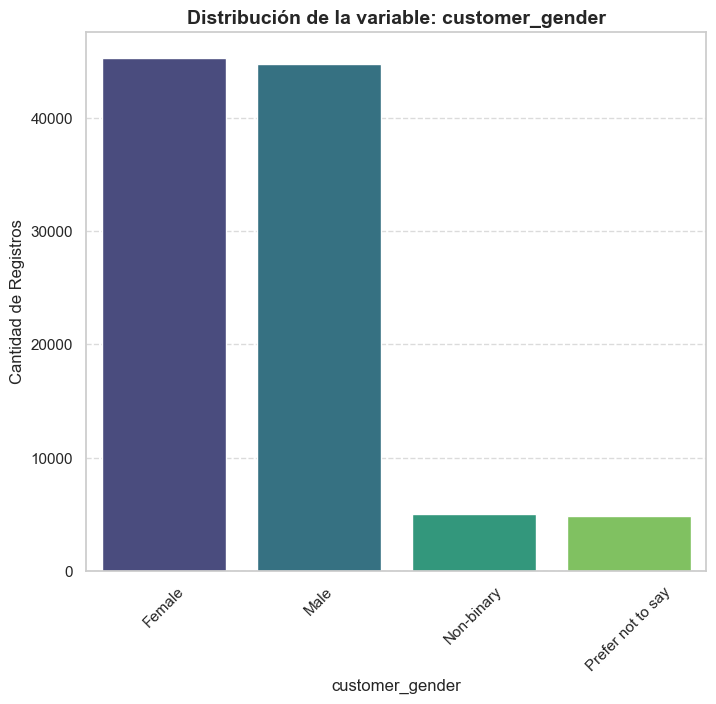

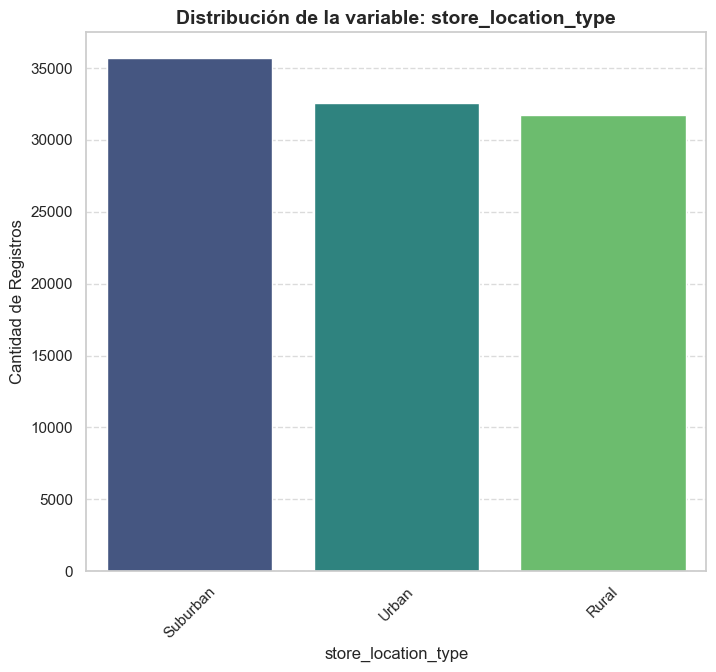

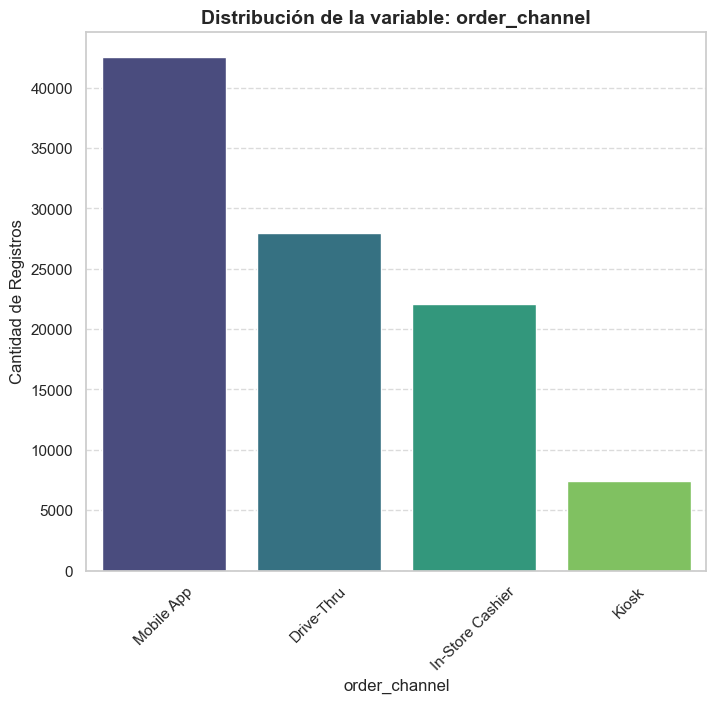

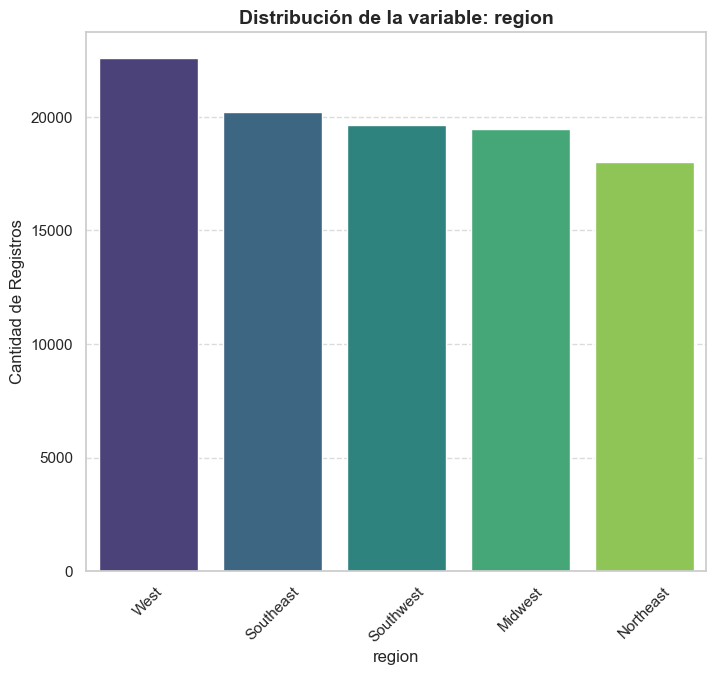

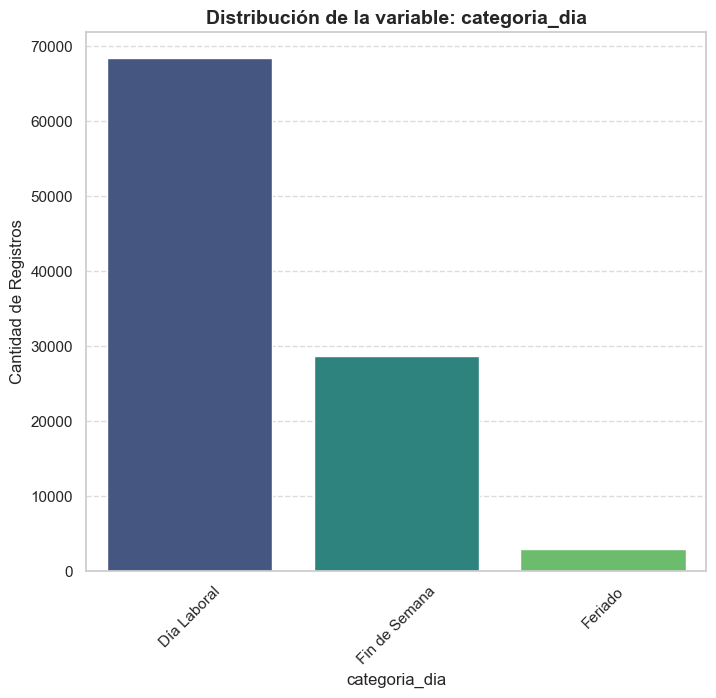

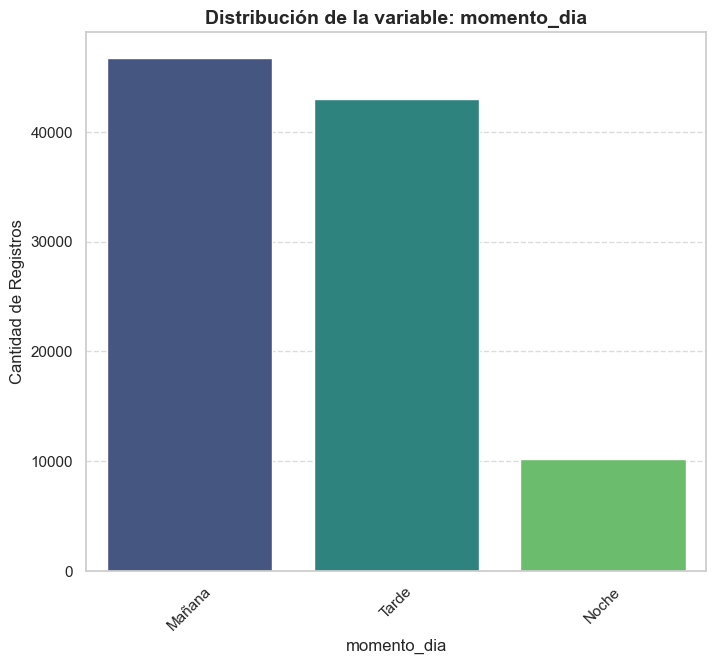

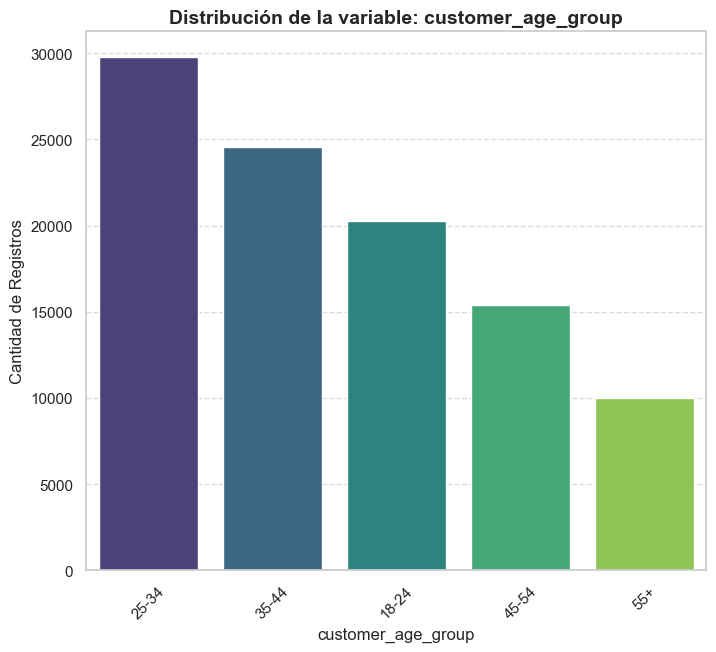

In [11]:
variables_categoricas = ['customer_gender', 'store_location_type', 'order_channel', 'region', 'categoria_dia', 'momento_dia', 'customer_age_group']

for col in variables_categoricas:
    plt.figure(figsize=(8, 7))
    
    # Grafica las barras ordenadas de mayor a menor frecuencia
    sns.countplot(
        data=df, 
        x=col, 
        order=df[col].value_counts().index, 
        palette='viridis'
    )
    
    plt.title(f'Distribución de la variable: {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Cantidad de Registros', fontsize=12)
    plt.xticks(rotation=45) # Por si los textos son largos
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    

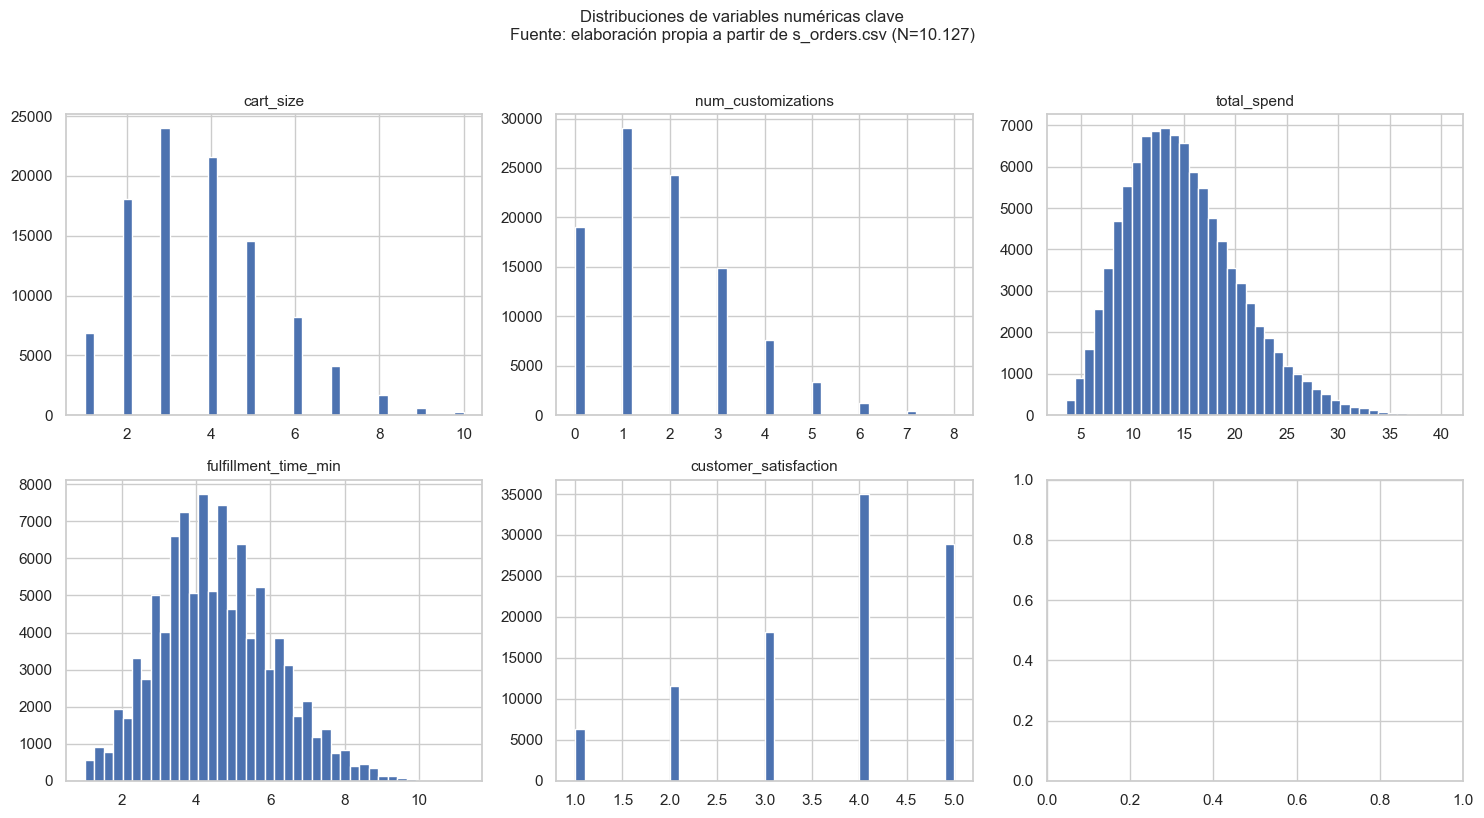

In [12]:
num_cols_eda = ['cart_size', 
    'num_customizations', 
    'total_spend', 
    'fulfillment_time_min', 
    'customer_satisfaction']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_cols_eda):
    ax.hist(df[col], bins=40, color='#4C72B0', edgecolor='white')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
    
fig.suptitle('Distribuciones de variables numéricas clave\nFuente: elaboración propia a partir de s_orders.csv (N=10.127)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

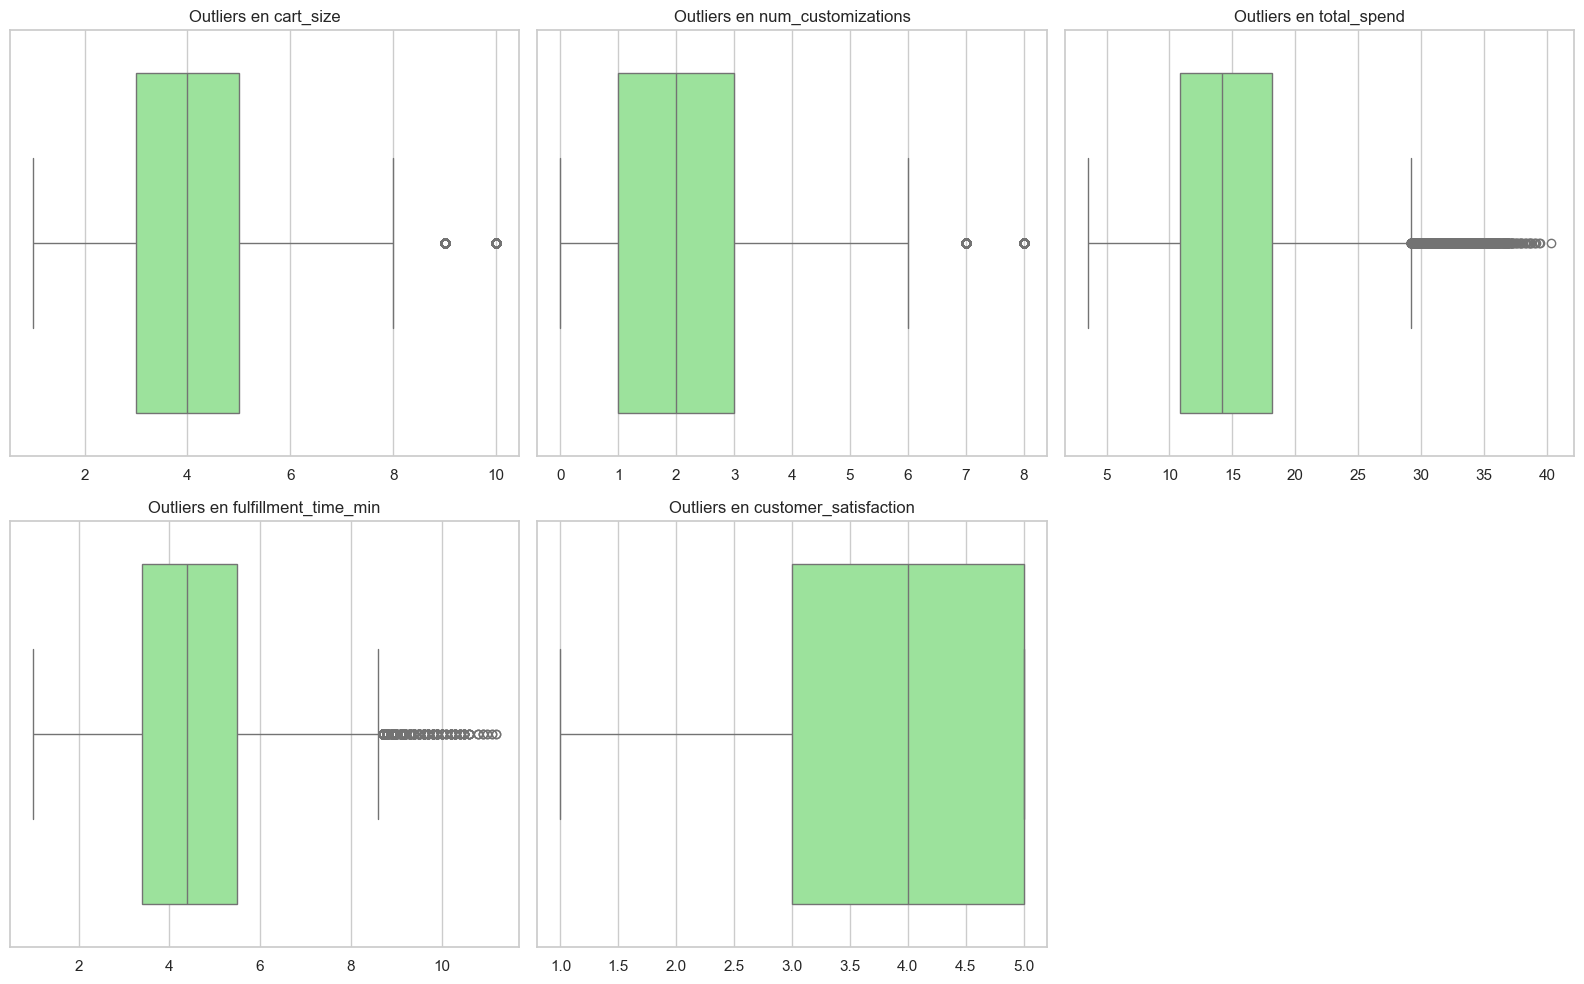

In [13]:
#Trataremos las variables numéricas y ver si hay que eliminar outliers.
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

# Lista de columnas numéricas para analizar
columnas_numericas = [
    'cart_size', 
    'num_customizations', 
    'total_spend', 
    'fulfillment_time_min', 
    'customer_satisfaction'
]

# Crear la figura con subplots
fig, axes = plt.subplots(2, 3)
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    sns.boxplot(x=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Outliers en {col}', fontsize=12)
    axes[i].set_xlabel('')

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

#no se eliminarán los outliers para ver si son son un grupo en específico

In [14]:
#df sin editar de respaldo
df_1 = df.copy()

#df para mapeo a mano para kmeans
df_2 = df.copy()

#df para rfm
df_rfm = df.copy()

#df para mapeo con one hot para kmeans
df_3 = df.copy()


In [15]:
#Realizaremos los mapeos
df_2 =df.copy()

store_location_map = {
    'Urban': 1,
    'Suburban': 2,
    'Rural': 3
}

df_2['store_location_type'] = df_2['store_location_type'].map(store_location_map)

age_group_map = {
    '18-24': 1,
    '25-34': 2,
    '35-44': 3,
    '45-54': 4,
    '55+': 5
}

df_2['customer_age_group'] = df_2['customer_age_group'].map(age_group_map)

customer_gender_map = {
    'Male': 1,
    'Female': 2,
    'Non-Binary': 3,
    'Prefer not to say': 4
}

df_2['customer_gender'] = df_2['customer_gender'].map(customer_gender_map)


categoria_dia_map = {
    'Día Laboral': 1,
    'Fin de Semana': 2,
    'Feriado': 3
}

df_2['categoria_dia'] = df_2['categoria_dia'].map(categoria_dia_map)

momento_dia_map = {
    'Mañana': 1,
    'Almuerzo': 2,
    'Tarde': 3,
    'Noche': 4
}

df_2['momento_dia'] = df_2['momento_dia'].map(momento_dia_map)

#Base 'Northeast' en regiones, por ser el centro de mayores negocios en USA
df_2['region'] = pd.Categorical(
    df_2['region'], 
    categories=['Northeast', 'Midwest', 'Southeast', 'Southwest', 'West'], 
    ordered=False
)

#Base 'In-Store Cashier' en canales, pues es la forma tradicional de comprar
df_2['order_channel'] = pd.Categorical(
    df_2['order_channel'], 
    categories=['In-Store Cashier', 'Drive-Thru', 'Kiosk', 'Mobile App'], 
    ordered=False
)

#Aplicamos One-Hot Encoding final a todas las nominales
df_2 = pd.get_dummies(
    df_2, 
    columns=['order_channel', 'region'], 
    drop_first=False
)

In [16]:
#Realizaremos los mapeos

df_3['store_location_type'] = pd.Categorical(
    df_3['store_location_type'], 
    categories=['Urban', 'Suburban', 'Rural'], 
    ordered=False
)

age_group_map = {
    '18-24': 1,
    '25-34': 2,
    '35-44': 3,
    '45-54': 4,
    '55+': 5
}

df_3['customer_age_group'] = df_3['customer_age_group'].map(age_group_map)


df_3['customer_gender'] = pd.Categorical(
    df_3['customer_gender'], 
    categories=['Male', 'Female', 'Non-binary', 'Prefer not to say'], 
    ordered=False
)

df_3['region'] = pd.Categorical(
    df_3['region'], 
    categories=['Northeast', 'Midwest', 'Southeast', 'Southwest', 'West'], 
    ordered=False
)

df_3['order_channel'] = pd.Categorical(
    df_3['order_channel'], 
    categories=['In-Store Cashier', 'Drive-Thru', 'Kiosk', 'Mobile App'], 
    ordered=False
)

#Aplicamos One-Hot Encoding final a todas las nominales
df_3 = pd.get_dummies(
    df_3, 
    columns=['order_channel', 'region','customer_gender', 'store_location_type'], 
    drop_first=False
)

In [17]:
df_2

,customer_id,order_id,order_date,order_time,day_of_week,store_id,store_location_type,customer_age_group,customer_gender,is_rewards_member,...,categoria_dia,order_channel_In-Store Cashier,order_channel_Drive-Thru,order_channel_Kiosk,order_channel_Mobile App,region_Northeast,region_Midwest,region_Southeast,region_Southwest,region_West
0,CUST_12974,ORD_00000001,2024-03-25,08:47:00,Mon,STR_340,2,1,1.000,False,...,1,False,True,False,False,False,False,False,True,False
1,CUST_08235,ORD_00000002,2025-07-18,08:02:00,Fri,STR_425,1,3,2.000,True,...,1,False,False,False,True,True,False,False,False,False
2,CUST_00393,ORD_00000003,2025-01-15,05:40:00,Wed,STR_103,2,2,2.000,False,...,1,False,False,True,False,False,True,False,False,False
3,CUST_06936,ORD_00000004,2024-07-30,15:10:00,Tue,STR_318,2,2,2.000,True,...,1,False,True,False,False,False,True,False,False,False
4,CUST_09800,ORD_00000005,2024-06-18,07:38:00,Tue,STR_338,2,3,2.000,False,...,1,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CUST_09857,ORD_00099996,2025-09-17,17:08:00,Wed,STR_016,2,4,NaN,True,...,1,False,False,False,True,True,False,False,False,False
99996,CUST_09970,ORD_00099997,2024-08-03,08:07:00,Sat,STR_409,3,3,4.000,True,...,2,False,True,False,False,False,False,False,True,False
99997,CUST_04417,ORD_00099998,2025-01-11,16:05:00,Sat,STR_191,2,5,2.000,False,...,2,True,False,False,False,True,False,False,False,False
99998,CUST_07997,ORD_00099999,2025-10-23,18:32:00,Thu,STR_210,3,1,2.000,True,...,1,False,False,False,True,False,False,True,False,False


In [18]:
df_3

,customer_id,order_id,order_date,order_time,day_of_week,store_id,customer_age_group,is_rewards_member,cart_size,num_customizations,...,region_Southeast,region_Southwest,region_West,customer_gender_Male,customer_gender_Female,customer_gender_Non-binary,customer_gender_Prefer not to say,store_location_type_Urban,store_location_type_Suburban,store_location_type_Rural
0,CUST_12974,ORD_00000001,2024-03-25,08:47:00,Mon,STR_340,1,False,5,0,...,False,True,False,True,False,False,False,False,True,False
1,CUST_08235,ORD_00000002,2025-07-18,08:02:00,Fri,STR_425,3,True,1,3,...,False,False,False,False,True,False,False,True,False,False
2,CUST_00393,ORD_00000003,2025-01-15,05:40:00,Wed,STR_103,2,False,2,1,...,False,False,False,False,True,False,False,False,True,False
3,CUST_06936,ORD_00000004,2024-07-30,15:10:00,Tue,STR_318,2,True,2,1,...,False,False,False,False,True,False,False,False,True,False
4,CUST_09800,ORD_00000005,2024-06-18,07:38:00,Tue,STR_338,3,False,3,1,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CUST_09857,ORD_00099996,2025-09-17,17:08:00,Wed,STR_016,4,True,4,0,...,False,False,False,False,False,True,False,False,True,False
99996,CUST_09970,ORD_00099997,2024-08-03,08:07:00,Sat,STR_409,3,True,5,2,...,False,True,False,False,False,False,True,False,False,True
99997,CUST_04417,ORD_00099998,2025-01-11,16:05:00,Sat,STR_191,5,False,3,0,...,False,False,False,False,True,False,False,False,True,False
99998,CUST_07997,ORD_00099999,2025-10-23,18:32:00,Thu,STR_210,1,True,5,1,...,True,False,False,False,True,False,False,False,False,True


**Modelo socio demográfico**

Métricas para K=1 completadas (Inercia solamente).
Métricas para K=2 completadas.
Métricas para K=3 completadas.
Métricas para K=4 completadas.
Métricas para K=5 completadas.
Métricas para K=6 completadas.
Métricas para K=7 completadas.
Métricas para K=8 completadas (Inercia solamente).
Métricas para K=9 completadas (Inercia solamente).
Métricas para K=10 completadas (Inercia solamente).


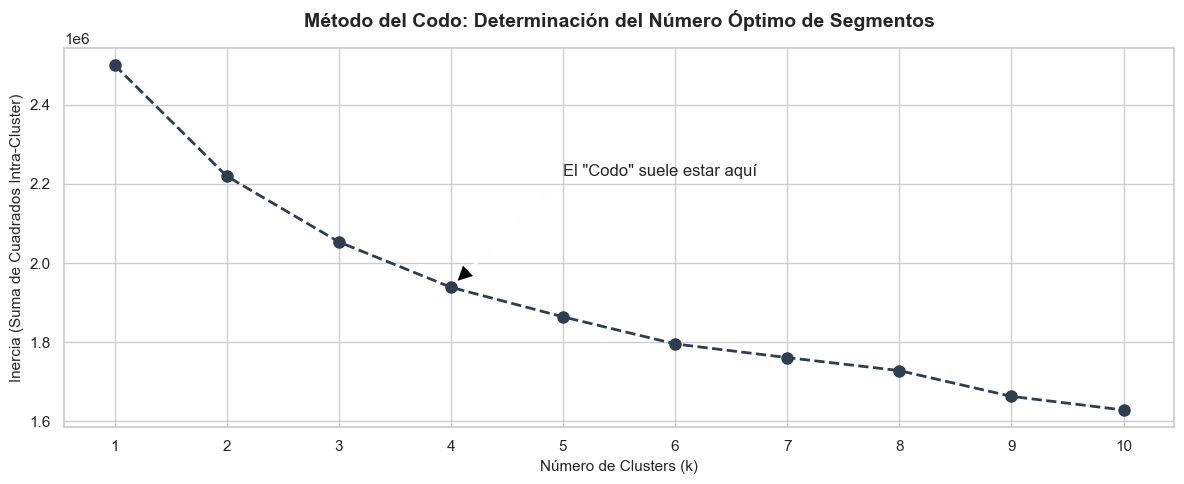

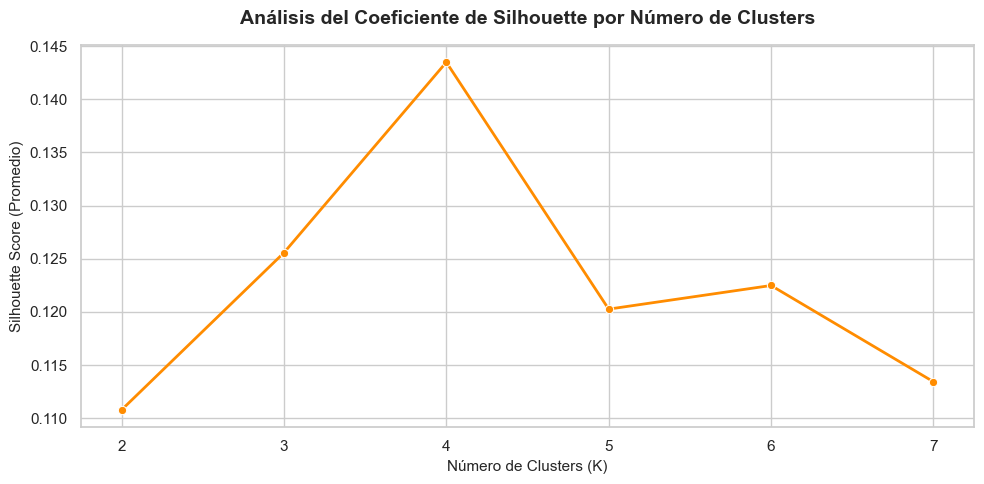


 TABLA COMPARATIVA DE MÉTRICAS


,K,inertia,silhouette
0,1,2500000.000,NaN
1,2,2219637.649,0.111
2,3,2053394.918,0.126
3,4,1938751.151,0.143
4,5,1864069.516,0.120
5,6,1795659.677,0.122
6,7,1761103.252,0.113
7,8,1728312.588,NaN
8,9,1663168.237,NaN
9,10,1628744.431,NaN


In [19]:
#Realizaremos el metodo del codo y silhouette para determinar el número óptimo de clusters con kmeans

# Preparación de los datos filtrando por tipos numéricos/booleanos
df_solo_num = df_3.select_dtypes(include=['number', 'bool', 'uint8'])

#Estandarización de los datos para mejorar la performance de KMeans
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_solo_num)

# Configuración de rangos y listas para almacenar métricas
k_rango = range(1, 11)
inercias = []
silhouette_dict = {} 

# Bucle único para calcular Inercia y Silhouette de forma eficiente
for k in k_rango:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    
    # Almacenar Inercia (Método del Codo)
    inercias.append(kmeans.inertia_)
    
    # Almacenar Silhouette (Requiere K >= 2)
    if k >= 2 and k <= 7: # Rango de tu ejemplo para Silhouette
        score = silhouette_score(df_scaled, labels)
        silhouette_dict[k] = score
        print(f"Métricas para K={k} completadas.")
    elif k == 1:
        print("Métricas para K=1 completadas (Inercia solamente).")
    else:
        print(f"Métricas para K={k} completadas (Inercia solamente).")

# Configuración del estilo visual general para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'


plt.figure(figsize=(12, 5))
plt.plot(k_rango, inercias, marker='o', markersize=8, linestyle='--', color='#2c3e50', linewidth=2)
plt.title('Método del Codo: Determinación del Número Óptimo de Segmentos', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Número de Clusters (k)', fontsize=11)
plt.ylabel('Inercia (Suma de Cuadrados Intra-Cluster)', fontsize=11)
plt.xticks(k_rango)

# Anotación sobre el codo
plt.annotate('El "Codo" suele estar aquí', 
             xy=(4, inercias[3]), 
             xytext=(5, inercias[1]),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))
plt.tight_layout()
plt.show()

#Gráfico de silhuette

k_rango_sil = range(2, 8)
# Extraemos los scores en el orden correcto del rango de Silhouette
scores_grafico = [silhouette_dict[k] for k in k_rango_sil]

plt.figure(figsize=(10, 5))
sns.lineplot(x=list(k_rango_sil), y=scores_grafico, marker='o', color='darkorange', linewidth=2)
plt.title('Análisis del Coeficiente de Silhouette por Número de Clusters', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Número de Clusters (K)', fontsize=11)
plt.ylabel('Silhouette Score (Promedio)', fontsize=11)
plt.xticks(k_rango_sil)
plt.tight_layout()
plt.show()

#Tabla comparativa entre Inercia y Silhouette
silhouettes_alineados = [silhouette_dict.get(k, None) for k in k_rango]

tabla_comparativa = pd.DataFrame({
    'K': list(k_rango), 
    'inertia': inercias, 
    'silhouette': silhouettes_alineados
}).round(3)

print("\n TABLA COMPARATIVA DE MÉTRICAS")
display(tabla_comparativa)

In [20]:
# 1. Definir el K óptimo según métricas
K_km = 4
RANDOM_STATE = 50

# 2. Inicializar el modelo K-Means
kmeans = KMeans(n_clusters=K_km, n_init=10, random_state=RANDOM_STATE)

# 3. Entrenar y predecir usando tu matriz de datos numéricos/escalados
# Nota: Si usas el DataFrame unificado anterior, cambia 'df_solo_num' por tu matriz escalada
df_3['Cluster_KMeans'] = kmeans.fit_predict(df_scaled)

# 4. Verificar la distribución de clientes por cada uno de los 3 segmentos
print("=== DISTRIBUCIÓN DE CLIENTES POR CLUSTER ===")
print(df_3['Cluster_KMeans'].value_counts().sort_index())

=== DISTRIBUCIÓN DE CLIENTES POR CLUSTER ===
Cluster_KMeans
0     7420
1    28063
2    22095
3    42422
Name: count, dtype: int64


In [21]:
#Probamos lo mismo pero con clases latentes ahora

#Seleccionamos las variables según su tipo para el descriptor mixto
gaussianas = ['total_spend', 'customer_satisfaction', 'fulfillment_time_min'] 

#No hay mapeo anterior, entregamos las variables de manera bruta pues stepmix realizar ese trabajo
df_1['customer_gender'] = df_1['customer_gender'].astype('category').cat.codes
df_1['store_location_type'] = df_1['store_location_type'].astype('category').cat.codes
df_1['order_channel'] = df_1['order_channel'].astype('category').cat.codes
df_1['region'] = df_1['region'].astype('category').cat.codes
df_1['categoria_dia'] = df_1['categoria_dia'].astype('category').cat.codes
df_1['momento_dia'] = df_1['momento_dia'].astype('category').cat.codes
df_1['customer_age_group'] = df_1['customer_age_group'].astype('category').cat.codes

#Dejamos las variables binarias
binarias = ['is_rewards_member']

mm_data, mm_descriptor = get_mixed_descriptor(
    dataframe=df_1, 
    gaussian=gaussianas,      
    categorical=variables_categoricas, 
    binary=binarias         
)

results = {}
for n_classes in range(2, 7):
    model = StepMix(n_components=n_classes, measurement=mm_descriptor, 
                    random_state=42, n_init=10, max_iter=100)
    model.fit(mm_data)
    results[n_classes] = {
        'aic': model.aic(mm_data),
        'bic': model.bic(mm_data),
        'log_likelihood': model.score(mm_data)
    }
    print(f"Clases={n_classes}: AIC={model.aic(mm_data):.1f}, BIC={model.bic(mm_data):.1f}")

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 10/10 [00:56<00:00,  5.67s/it, max_LL=-1.94e+6, max_avg_LL=-19.4]


Clases=2: AIC=3874193.5, BIC=3874659.6
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 10/10 [02:28<00:00, 14.84s/it, max_LL=-1.71e+6, max_avg_LL=-17.1]


Clases=3: AIC=3417413.4, BIC=3418117.3
Fitting StepMix...


...

Clases=4: AIC=3252408.2, BIC=3253350.0
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 10/10 [03:06<00:00, 18.66s/it, max_LL=-1.59e+6, max_avg_LL=-15.9]


Clases=5: AIC=3178059.7, BIC=3179239.3
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 10/10 [03:16<00:00, 19.62s/it, max_LL=-1.57e+6, max_avg_LL=-15.7]


Clases=6: AIC=3134062.6, BIC=3135480.1


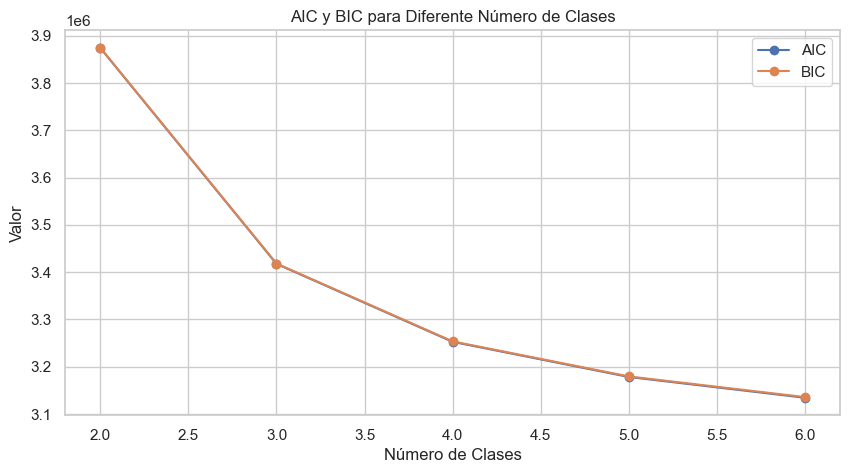

In [22]:
#Graficar AIC y BIC para cada número de clases
aic_values = [results[n]['aic'] for n in results]
bic_values = [results[n]['bic'] for n in results]
plt.figure(figsize=(10, 5))
plt.plot(list(results.keys()), aic_values, marker='o', label='AIC')
plt.plot(list(results.keys()), bic_values, marker='o', label='BIC')
plt.xlabel('Número de Clases')
plt.ylabel('Valor')
plt.title('AIC y BIC para Diferente Número de Clases')
plt.legend()
plt.show()

In [23]:
model = StepMix(n_components=4, measurement=mm_descriptor, verbose=1, random_state=123)
model.fit(mm_data)
df_1['mixed_pred_rfm'] = model.predict(mm_data)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:18<00:00, 18.26s/it, max_LL=-1.63e+6, max_avg_LL=-16.3]


MODEL REPORT
    Measurement model parameters
          model_name                  gaussian                    
          class_no                           0      1     2      3
          param variable                                          
          means customer_satisfaction    3.834  3.777 3.583  3.679
                fulfillment_time_min     4.536  4.516 4.579  4.543
                total_spend             26.489 19.369 8.936 13.987


          model_name                  categorical                  
          class_no                              0     1     2     3
          param variable                                           
          pis   categoria_dia_0             0.681 0.680 0.689 0.685
                categoria_dia_1             0.029 0.029 0.029 0.029
                categoria_dia_2             0.290 0.291 0.282 0.286
                customer_age_group_0        0.256 0.229 0.174 0.196
                customer_age_group_1        0.372 0.339 0.253 0.290
      

In [24]:
# Cambia 'Cluster_KMeans' por el nombre exacto de la columna en tu df_3
columnas_numericas = ['total_spend', 'customer_satisfaction', 'fulfillment_time_min', 'is_rewards_member']

print("=== PROMEDIOS POR SEGMENTO EN K-MEANS ===")
display(df_3.groupby('Cluster_KMeans')[columnas_numericas].mean().round(2))


=== PROMEDIOS POR SEGMENTO EN K-MEANS ===


,total_spend,customer_satisfaction,fulfillment_time_min,is_rewards_member
Cluster_KMeans,,,,
0,12.490,3.600,4.010,0.340
1,12.460,3.440,5.810,0.350
2,12.500,3.700,3.200,0.350
3,18.100,3.860,4.510,0.650


In [25]:
# 1. Usamos una copia limpia de tus datos para recuperar los textos originales
df_completo = df_1.copy()

# 2. Re-aislamos las variables continuas para asegurar que el modelo corra sin errores de dimensiones
columnas_modelo = ['total_spend', 'customer_satisfaction', 'fulfillment_time_min']
X_vars = df_completo[columnas_modelo].values

# Forzamos n_components=4 para tus 4 segmentos
model_4_clusters = StepMix(n_components=4, measurement='gaussian', random_state=42, n_init=5)
model_4_clusters.fit(X_vars)

# Guardamos las etiquetas de tus 4 grupos (0, 1, 2 y 3)
df_completo['Cluster_LCA'] = model_4_clusters.predict(X_vars)

# Función segura para extraer la palabra/categoría más común en cada cluster
def obtener_moda(x):
    res = x.mode()
    return res.iloc[0] if not res.empty else None

# Creamos el diccionario con el 100% de tus variables
diccionario_agregacion = {
    'total_spend': 'mean',
    'customer_satisfaction': 'mean',
    'fulfillment_time_min': 'mean',
    'cart_size': 'mean',
    'num_customizations': 'mean',
    'is_rewards_member': 'mean',   # % de miembros de Rewards
    'has_food_item': 'mean',       # % que pidió comida
    'order_ahead': 'mean',         # % que pidió por adelantado
    'order_channel': obtener_moda,
    'store_location_type': obtener_moda,
    'region': obtener_moda,
    'customer_age_group': obtener_moda,
    'customer_gender': obtener_moda,
    'drink_category': obtener_moda
}

# Agrupamos por tus 4 clusters y aplicamos las métricas correspondientes
tabla_maestra = df_completo.groupby('Cluster_LCA').agg(diccionario_agregacion).round(2)

# Añadimos cuántos clientes reales tiene cada uno de los 4 grupos
tabla_maestra['Cantidad_Clientes'] = df_completo['Cluster_LCA'].value_counts().sort_index().values
tabla_maestra['%_Clientes'] = ((tabla_maestra['Cantidad_Clientes'] / len(df_completo)) * 100).round(2)

# Desplegamos la tabla completa horizontal
display(tabla_maestra)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 5/5 [00:49<00:00,  9.87s/it, max_LL=-7.54e+5, max_avg_LL=-7.54]


,total_spend,customer_satisfaction,fulfillment_time_min,cart_size,num_customizations,is_rewards_member,has_food_item,order_ahead,order_channel,store_location_type,region,customer_age_group,customer_gender,drink_category,Cantidad_Clientes,%_Clientes
Cluster_LCA,,,,,,,,,,,,,,,,
0,19.400,3.770,4.520,4.980,2.350,0.550,0.400,0.470,3,1,4,1,0,Tea,24298,24.300
1,26.520,3.830,4.540,6.960,2.990,0.620,0.490,0.640,3,1,4,1,0,Tea,8357,8.360
2,14.000,3.680,4.540,3.530,1.730,0.460,0.310,0.260,3,1,4,1,1,Refresher,37916,37.920
3,8.920,3.590,4.580,2.070,1.140,0.390,0.200,0.100,0,1,4,2,0,Espresso,29429,29.430


In [26]:
#Gráfico 3d
#Genera un grafico en 3D para visualizar como quedo el modelo de clases latentes usando plotly express
import plotly.express as px
fig = px.scatter_3d(
    df_1, 
    x='total_spend', 
    y='customer_satisfaction', 
    z='fulfillment_time_min', 
    color='mixed_pred_rfm',
    title='Visualización 3D de Clases Latentes (StepMix)',
    labels={'total_spend': 'Gasto Total', 'customer_satisfaction': 'Satisfacción del Cliente', 'fulfillment_time_min': 'Tiempo de Cumplimiento (min)'},
    color_continuous_scale=px.colors.qualitative.Set1
)
fig.update_layout(legend_title_text='Clase Latente')
fig.show()

In [27]:
#k automático según BIC
bics_lista = [results[k]['bic'] for k in range(2, 7)]
ks_lca = list(range(2, 7))
K_lca_auto = ks_lca[np.argmin(bics_lista)]

#Forzamos K=4 basado en el análisis de parsimonia anterior
K_lca = 4  

print(f"K óptimo estrictamente según BIC: {K_lca_auto}")
print(f"K seleccionado para el modelo final: {K_lca}\n")

# Usamos el mm_descriptor mixto que configuramos previamente
lca_final = StepMix(
    n_components=K_lca, 
    measurement=mm_descriptor,
    n_init=5,            # Un número saludable para evitar mínimos locales
    max_iter=1000,       # Garantiza convergencia en tus 100k filas
    random_state=42, 
    verbose=0,
    progress_bar=0
)

# Entrenamos el modelo final
lca_final.fit(mm_data)

# Guardamos las asignaciones de clases latentes en tu DataFrame original de transacciones
df_1['Cluster_LCA'] = lca_final.predict(mm_data)

# Generamos la matriz de probabilidades (tamaño: 100000 filas x 3 columnas)
probs = lca_final.predict_proba(mm_data)

# Guardamos la probabilidad máxima con la que el modelo asignó cada cliente a su clase
df_1['LCA_Prob_Max'] = probs.max(axis=1)

print("DISTRIBUCIÓN DE CLIENTES POR CLASE LATENTE")
print(df_1['Cluster_LCA'].value_counts().sort_index())

print(f"\nProbabilidad de pertenencia mediana: {df_1['LCA_Prob_Max'].median():.3f}")

# Clientes en la frontera: el modelo no estuvo seguro de dónde ponerlos
clientes_borderline = (df_1['LCA_Prob_Max'] < 0.6).sum()
porcentaje_borderline = (clientes_borderline / len(df_1)) * 100

print(f"Clientes 'borderline' (prob max < 0.6): {clientes_borderline} ({porcentaje_borderline:.2f}%)")

K óptimo estrictamente según BIC: 6
K seleccionado para el modelo final: 4

DISTRIBUCIÓN DE CLIENTES POR CLASE LATENTE
Cluster_LCA
0     8394
1    37741
2    24408
3    29457
Name: count, dtype: int64

Probabilidad de pertenencia mediana: 1.000
Clientes 'borderline' (prob max < 0.6): 2316 (2.32%)


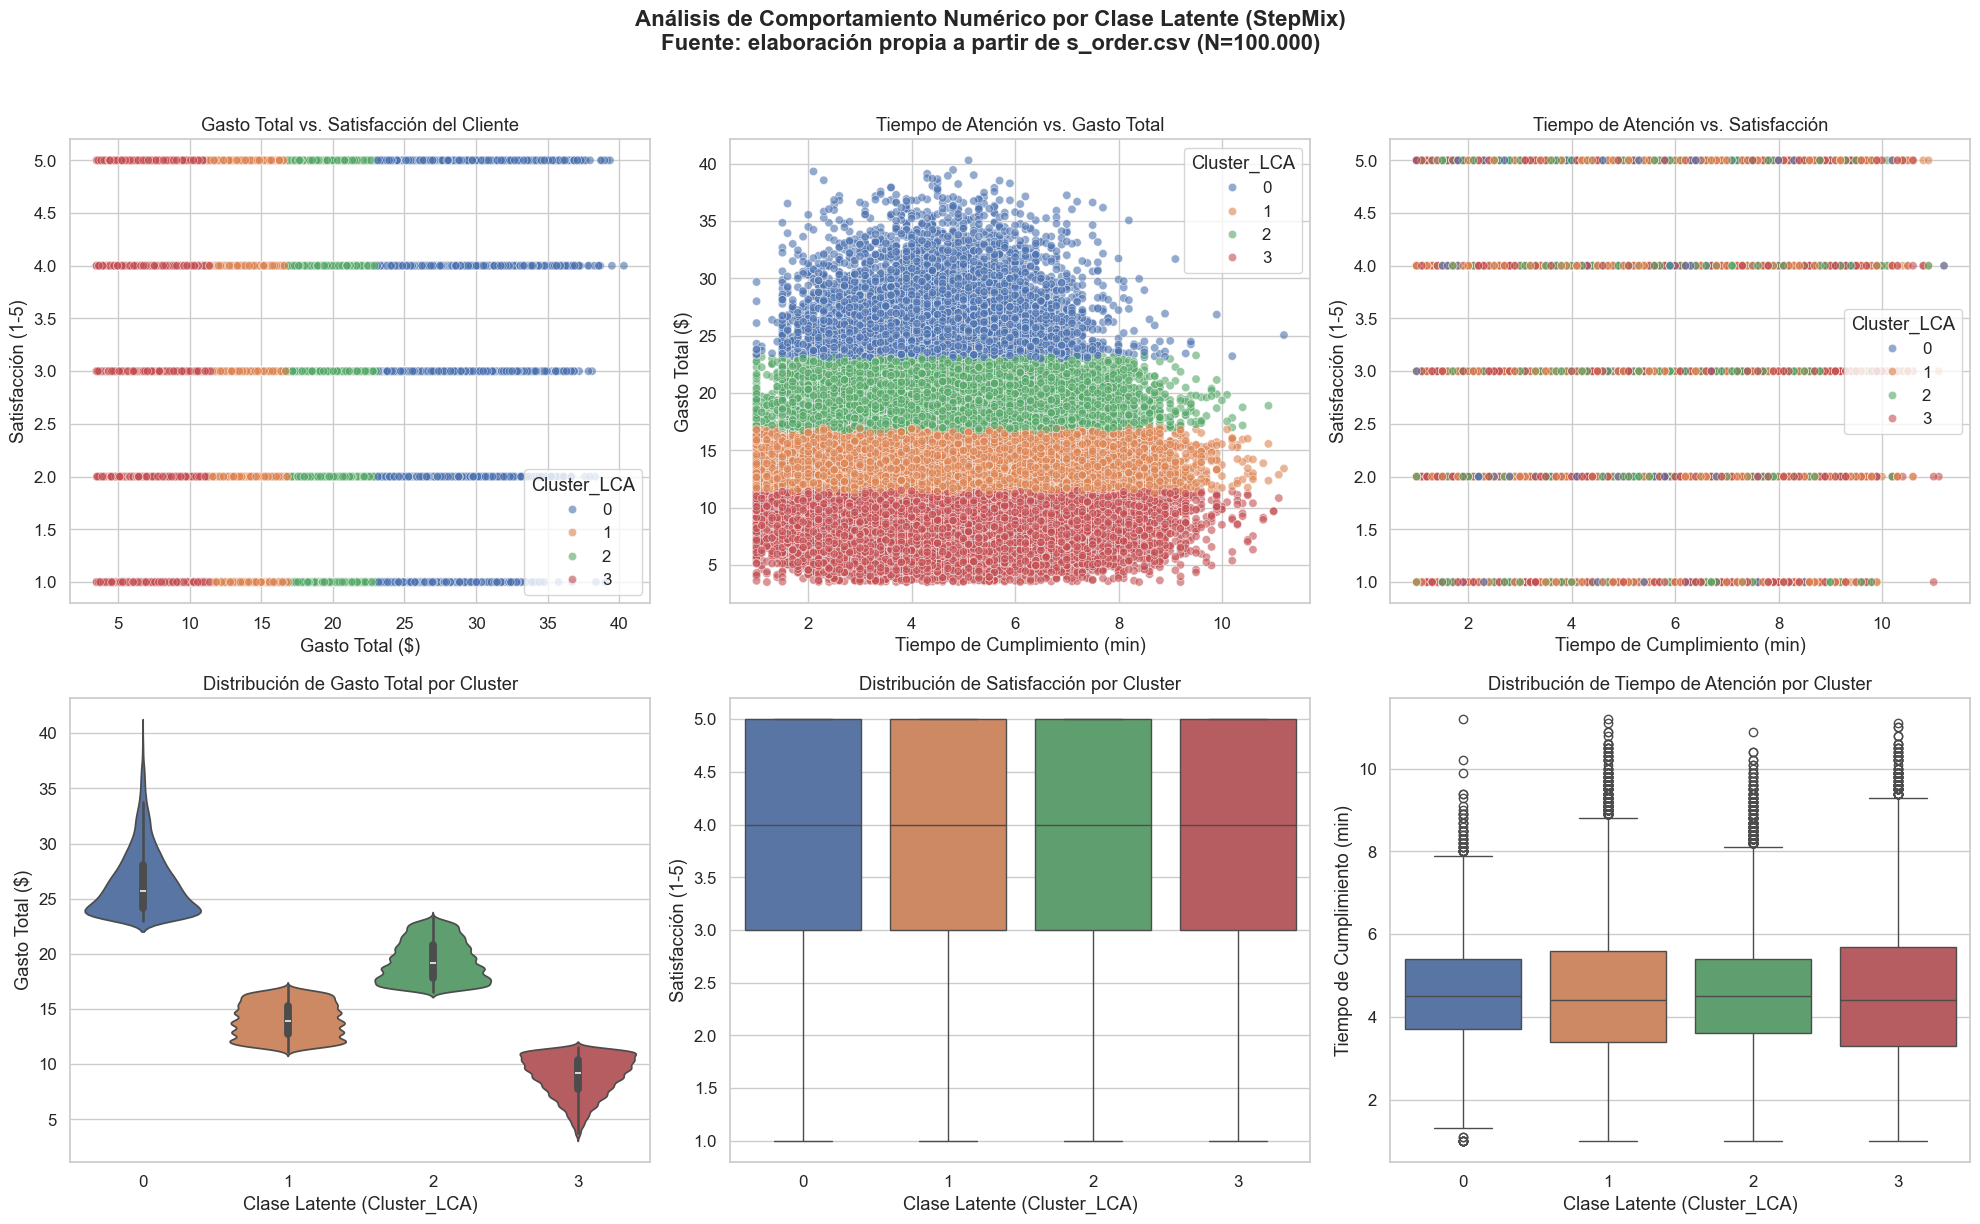

In [28]:
sns.set_theme(style="whitegrid", font_scale=1.1)

# Crear figura de 2 filas y 3 columnas para el perfil sociodemográfico
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# Paleta basada en la cantidad de clases latentes (Cluster_LCA)
num_clusters_lca = df_1['Cluster_LCA'].nunique()
palette = sns.color_palette("deep", num_clusters_lca)

# Gráfico 1: total_spend vs customer_satisfaction
sns.scatterplot(data=df_1, x='total_spend', y='customer_satisfaction', hue='Cluster_LCA',
                palette=palette, alpha=0.6, ax=axes[0])
axes[0].set_title('Gasto Total vs. Satisfacción del Cliente')
axes[0].set_xlabel('Gasto Total ($)')
axes[0].set_ylabel('Satisfacción (1-5)')

# Gráfico 2: fulfillment_time_min vs total_spend
sns.scatterplot(data=df_1, x='fulfillment_time_min', y='total_spend', hue='Cluster_LCA',
                palette=palette, alpha=0.6, ax=axes[1])
axes[1].set_title('Tiempo de Atención vs. Gasto Total')
axes[1].set_xlabel('Tiempo de Cumplimiento (min)')
axes[1].set_ylabel('Gasto Total ($)')

# Gráfico 3: fulfillment_time_min vs customer_satisfaction
sns.scatterplot(data=df_1, x='fulfillment_time_min', y='customer_satisfaction', hue='Cluster_LCA',
                palette=palette, alpha=0.6, ax=axes[2])
axes[2].set_title('Tiempo de Atención vs. Satisfacción')
axes[2].set_xlabel('Tiempo de Cumplimiento (min)')
axes[2].set_ylabel('Satisfacción (1-5)')


# --- FILA 2: DISTRIBUCIONES POR CLUSTER (VIOLIN & BOX PLOTS) ---

# Gráfico 4: Diagrama de violín de total_spend por cluster
sns.violinplot(data=df_1, x='Cluster_LCA', y='total_spend', palette=palette, ax=axes[3])
axes[3].set_title('Distribución de Gasto Total por Cluster')
axes[3].set_xlabel('Clase Latente (Cluster_LCA)')
axes[3].set_ylabel('Gasto Total ($)')

# Gráfico 5: Diagrama de caja de customer_satisfaction por cluster
sns.boxplot(data=df_1, x='Cluster_LCA', y='customer_satisfaction', palette=palette, ax=axes[4])
axes[4].set_title('Distribución de Satisfacción por Cluster')
axes[4].set_xlabel('Clase Latente (Cluster_LCA)')
axes[4].set_ylabel('Satisfacción (1-5)')

# Gráfico 6: Diagrama de caja de fulfillment_time_min por cluster
sns.boxplot(data=df_1, x='Cluster_LCA', y='fulfillment_time_min', palette=palette, ax=axes[5])
axes[5].set_title('Distribución de Tiempo de Atención por Cluster')
axes[5].set_xlabel('Clase Latente (Cluster_LCA)')
axes[5].set_ylabel('Tiempo de Cumplimiento (min)')

# Ajustar diseño formal para evitar solapamiento de textos
plt.suptitle('Análisis de Comportamiento Numérico por Clase Latente (StepMix)\n'
             'Fuente: elaboración propia a partir de s_order.csv (N=100.000)', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

**Segmentación RFM** 

In [29]:
# Establecemos la fecha de corte (un día después de la última orden registrada)
df_rfm['order_date'] = pd.to_datetime(df_rfm['order_date'])
fecha_corte = df_rfm['order_date'].max() + pd.Timedelta(days=1)

# Agrupamos el histórico de transacciones por cada cliente único
df_rfm = df_rfm.groupby('customer_id').agg({
    'order_date': lambda x: (fecha_corte - x.max()).days, # Recency en días reales
    'order_id': 'nunique',                                # Frequency (Órdenes únicas)
    'total_spend': 'sum'                                  # Monetary (Gasto total acumulado)
}).rename(columns={
    'order_date': 'Recency_days',
    'order_id': 'Frequency',
    'total_spend': 'Monetary'
})

# Convertimos los días de inactividad en un puntaje lineal positivo:
# A menor cantidad de días desde la última compra, mayor será el valor en 'Recency'.
df_rfm['Recency'] = df_rfm['Recency_days'].max() - df_rfm['Recency_days']

# Definimos las columnas clave para el posterior clustering geométrico
Columnas_rfm = ['Recency', 'Frequency', 'Monetary']

# Creamos el DataFrame limpio para el análisis estadístico del negocio
df_rfm_analisis = df_rfm[Columnas_rfm].copy()

print("VISTA PREVIA DE LAS MÉTRICAS CALCULADAS (HEAD)")
display(df_rfm_analisis.head())

print("\nESTADÍSTICAS DESCRIPTIVAS PARA EL INFORME (ESCALA REAL)")
display(df_rfm_analisis.describe().round(2))

VISTA PREVIA DE LAS MÉTRICAS CALCULADAS (HEAD)


,Recency,Frequency,Monetary
customer_id,,,
CUST_00001,687,12,174.600
CUST_00002,666,13,207.180
CUST_00003,644,5,79.710
CUST_00004,582,7,95.850
CUST_00005,648,3,47.450



ESTADÍSTICAS DESCRIPTIVAS PARA EL INFORME (ESCALA REAL)


,Recency,Frequency,Monetary
count,14988.000,14988.000,14988.000
mean,619.410,6.670,99.190
std,105.030,2.560,40.970
min,0.000,1.000,3.830
25%,575.000,5.000,69.790
50%,652.000,6.000,95.600
75%,696.000,8.000,124.860
max,727.000,18.000,301.680


In [30]:
df_rfm_scores = df_rfm.copy()

#Asignación de Scores del 1 al 4 usando Cuartiles (q=4)
# Usamos .rank(method='first') para desempatar clientes con métricas idénticas (como la Frecuencia)
df_rfm_scores['R_score'] = pd.qcut(df_rfm_scores['Recency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
df_rfm_scores['F_score'] = pd.qcut(df_rfm_scores['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
df_rfm_scores['M_score'] = pd.qcut(df_rfm_scores['Monetary'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)

df_rfm_scores['RFM_Score'] = (
    df_rfm_scores['R_score'].astype(str) +
    df_rfm_scores['F_score'].astype(str) +
    df_rfm_scores['M_score'].astype(str)
)

#Mostrar el Top 10 de las combinaciones más comunes en tu negocio
print("TOP 10 COMBINACIONES RFM MÁS COMUNES")
print(df_rfm_scores['RFM_Score'].value_counts().head(10))

TOP 10 COMBINACIONES RFM MÁS COMUNES
RFM_Score
111    1364
444    1093
344     934
211     705
244     657
433     610
122     584
233     583
222     578
333     575
Name: count, dtype: int64


Calculando métricas de optimización para K-Means tradicional
K=2 evaluado exitosamente.
K=3 evaluado exitosamente.
K=4 evaluado exitosamente.
K=5 evaluado exitosamente.
K=6 evaluado exitosamente.
K=7 evaluado exitosamente.
K=8 evaluado exitosamente.
Cálculos completados. Generando visualizaciones


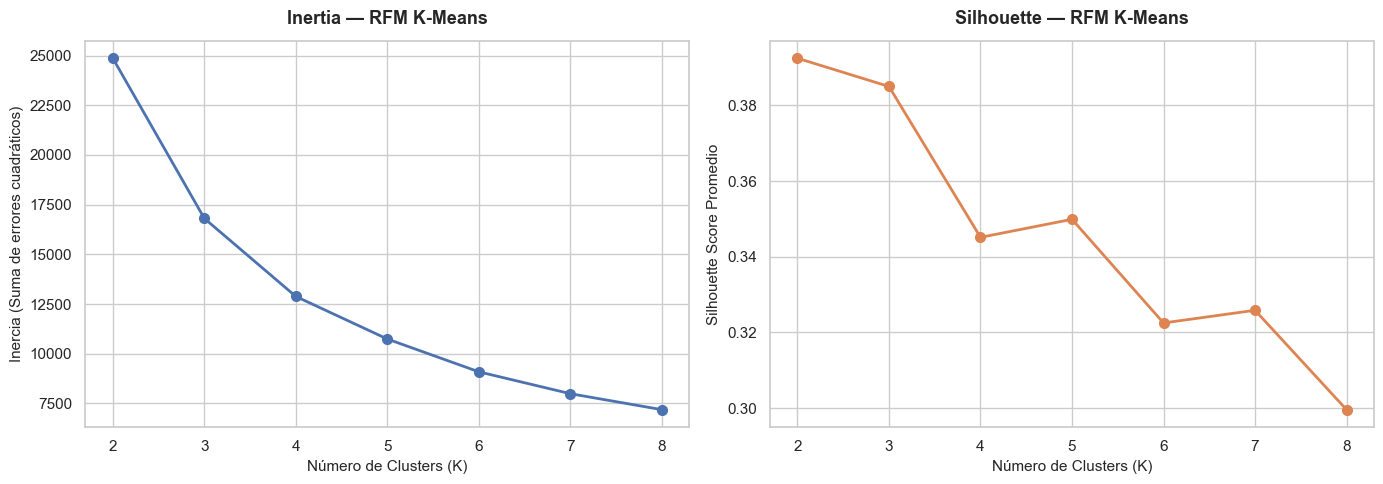

In [31]:
#Aplicaciones de k means para el modelo de rfm

RANDOM_STATE = 42

df_rfm_copia = df_rfm.copy()

#SEPARACIÓN Y ESTANDARIZACIÓN
columnas_modelo = ['Recency', 'Frequency', 'Monetary']
X_rfm = StandardScaler().fit_transform(df_rfm_copia[columnas_modelo])

#BUCLE DE EVALUACIÓN (Inercia y Silhouette)
inertias_rfm, sils_rfm = [], []
k_rango = range(2, 9)

print("Calculando métricas de optimización para K-Means tradicional")
for k in k_rango:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    lab = km.fit_predict(X_rfm)
    
    inertias_rfm.append(km.inertia_)
    # Usamos sample_size=3000 como tu ejemplo para que el cálculo no tarde tanto en tus 100k filas
    sils_rfm.append(silhouette_score(X_rfm, lab, sample_size=3000, random_state=RANDOM_STATE))
    print(f"K={k} evaluado exitosamente.")

print("Cálculos completados. Generando visualizaciones")

#Gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Inercia (Método del Codo)
axes[0].plot(k_rango, inertias_rfm, marker='o', linewidth=2, color='#4C72B0', markersize=7)
axes[0].set_title('Inertia — RFM K-Means', fontsize=13, pad=12, fontweight='bold')
axes[0].set_xlabel('Número de Clusters (K)', fontsize=11)
axes[0].set_ylabel('Inercia (Suma de errores cuadráticos)', fontsize=11)
axes[0].set_xticks(k_rango)

# Gráfico de Coeficiente de Silhouette
axes[1].plot(k_rango, sils_rfm, marker='o', linewidth=2, color='#DD8452', markersize=7)
axes[1].set_title('Silhouette — RFM K-Means', fontsize=13, pad=12, fontweight='bold')
axes[1].set_xlabel('Número de Clusters (K)', fontsize=11)
axes[1].set_ylabel('Silhouette Score Promedio', fontsize=11)
axes[1].set_xticks(k_rango)

plt.tight_layout()
plt.show()

In [32]:
# Entrenamos el modelo definitivo con K=4
km_final = KMeans(n_clusters=4, n_init=10, random_state=42)
df_rfm_copia['Cluster_RFM'] = km_final.fit_predict(X_rfm)

# Agrupamos para ver los promedios reales de cada grupo
resumen = df_rfm_copia.groupby('Cluster_RFM')[['Recency_days', 'Frequency', 'Monetary']].mean().round(1)
print(resumen)

             Recency_days  Frequency  Monetary
Cluster_RFM                                   
0                  62.500     10.600   162.000
1                 316.400      4.200    61.800
2                  79.400      7.400   109.700
3                  82.000      4.600    65.000


In [33]:
K_rfm = 4
RANDOM_STATE = 42

km_rfm = KMeans(n_clusters=K_rfm, n_init=10, random_state=RANDOM_STATE)

# Entrenamos con la matriz escalada (X_rfm) pero guardamos el resultado en el DataFrame original
df_rfm_copia['Cluster_RFM'] = km_rfm.fit_predict(X_rfm)

# Agrupamos por el nuevo cluster y calculamos la media de tus variables originales
perfil_rfm = df_rfm_copia.groupby('Cluster_RFM')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

# Renombramos las columnas para que el reporte quede perfectamente ejecutivo
perfil_rfm.columns = ['Recency (Días inactivo promedio)', 'Frequency (N° órdenes promedio)', 'Monetary (Gasto total promedio)']

# Añadimos el conteo de cuántos clientes cayeron en cada grupo
perfil_rfm['N° Clientes'] = df_rfm_copia['Cluster_RFM'].value_counts().sort_index().values

# Calculamos el porcentaje que representa cada grupo sobre el total del negocio
total_clientes = perfil_rfm['N° Clientes'].sum()
perfil_rfm['% Clientes'] = ((perfil_rfm['N° Clientes'] / total_clientes) * 100).round(2)

print("PERFIL ESTRATÉGICO DE LOS CLUSTERS K-MEANS")
display(perfil_rfm)

PERFIL ESTRATÉGICO DE LOS CLUSTERS K-MEANS


,Recency (Días inactivo promedio),Frequency (N° órdenes promedio),Monetary (Gasto total promedio),N° Clientes,% Clientes
Cluster_RFM,,,,,
0,665.510,10.550,161.970,2691,17.950
1,411.650,4.190,61.770,1990,13.280
2,648.620,7.360,109.720,5769,38.490
3,646.050,4.580,64.990,4538,30.280


In [34]:
resumen_RFM = df_rfm_copia.groupby('Cluster_RFM').agg(
    recency_promedio=('Recency_days', 'mean'),
    transacciones_promedio=('Frequency', 'mean'),
    gasto_promedio=('Monetary', 'mean'),
    cantidad=('Cluster_RFM', 'size')
).reset_index()

# Calculamos el porcentaje de clientes para complementar el análisis
total_clientes = resumen_RFM['cantidad'].sum()
resumen_RFM['porcentaje_clientes'] = ((resumen_RFM['cantidad'] / total_clientes) * 100).round(2)

columnas_num = ['recency_promedio', 'transacciones_promedio', 'gasto_promedio']
resumen_RFM[columnas_num] = resumen_RFM[columnas_num].round(1)

print("Tabla resumen de starbucks")
display(resumen_RFM)

Tabla resumen de starbucks


,Cluster_RFM,recency_promedio,transacciones_promedio,gasto_promedio,cantidad,porcentaje_clientes
0,0,62.500,10.600,162.000,2691,17.950
1,1,316.400,4.200,61.800,1990,13.280
2,2,79.400,7.400,109.700,5769,38.490
3,3,82.000,4.600,65.000,4538,30.280


In [35]:
#Aplicación de clase latente para el modelo de rfm 
mixed_data_rfm, mixed_descriptor_rfm = get_mixed_descriptor(
    dataframe=df_rfm,
    gaussian=['Recency_days', 'Frequency', 'Monetary']
)


model = StepMix(n_components=4, measurement=mixed_descriptor_rfm, verbose=1, random_state=0)
model.fit(mixed_data_rfm)
df_rfm['mixed_pred_rfm'] = model.predict(mixed_data_rfm)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:01<00:00,  1.40s/it, max_LL=-1.99e+7, max_avg_LL=-1.33e+3]

MODEL REPORT
    Measurement model parameters
          model_name         gaussian                       
          class_no                  0       1       2      3
          param variable                                    
          means Frequency       9.383   4.117   6.059  5.620
                Monetary      145.316  61.900  89.605 79.523
                Recency_days   41.789 380.303 180.512 55.614


    Class weights
        Class 1 : 0.28
        Class 2 : 0.07
        Class 3 : 0.26
        Class 4 : 0.39
    Fit for 4 latent classes
    Estimation method             : 1-step
    Number of observations        : 14988
    Number of latent classes      : 4
    Number of estimated parameters: 15
    Log-likelihood (LL)           : -19880493.3703
    -2LL                          : 39760986.7407
    Average LL                    : -1326.4274
    AIC                           : 39761016.74
    BIC                           : 39761130.97
    CAIC                          : 39761

In [36]:
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler

radar_cols = ['Recency_days', 'Frequency', 'Monetary']
scaler_r = MinMaxScaler()
df_r = df_rfm_copia.copy()
df_r[radar_cols] = scaler_r.fit_transform(df_r[radar_cols])
centroides_r = df_r.groupby('Cluster_RFM')[radar_cols].mean().reset_index()

fig = go.Figure()
for _, row in centroides_r.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=row[radar_cols].values.tolist() + [row[radar_cols].values[0]],
        theta=radar_cols + [radar_cols[0]],
        fill='toself',
        name=f'Cluster {int(row["Cluster_RFM"])}'
    ))
fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title='Huella de consumo por segmento (escala 0–1)',
    showlegend=True
)
fig.show()

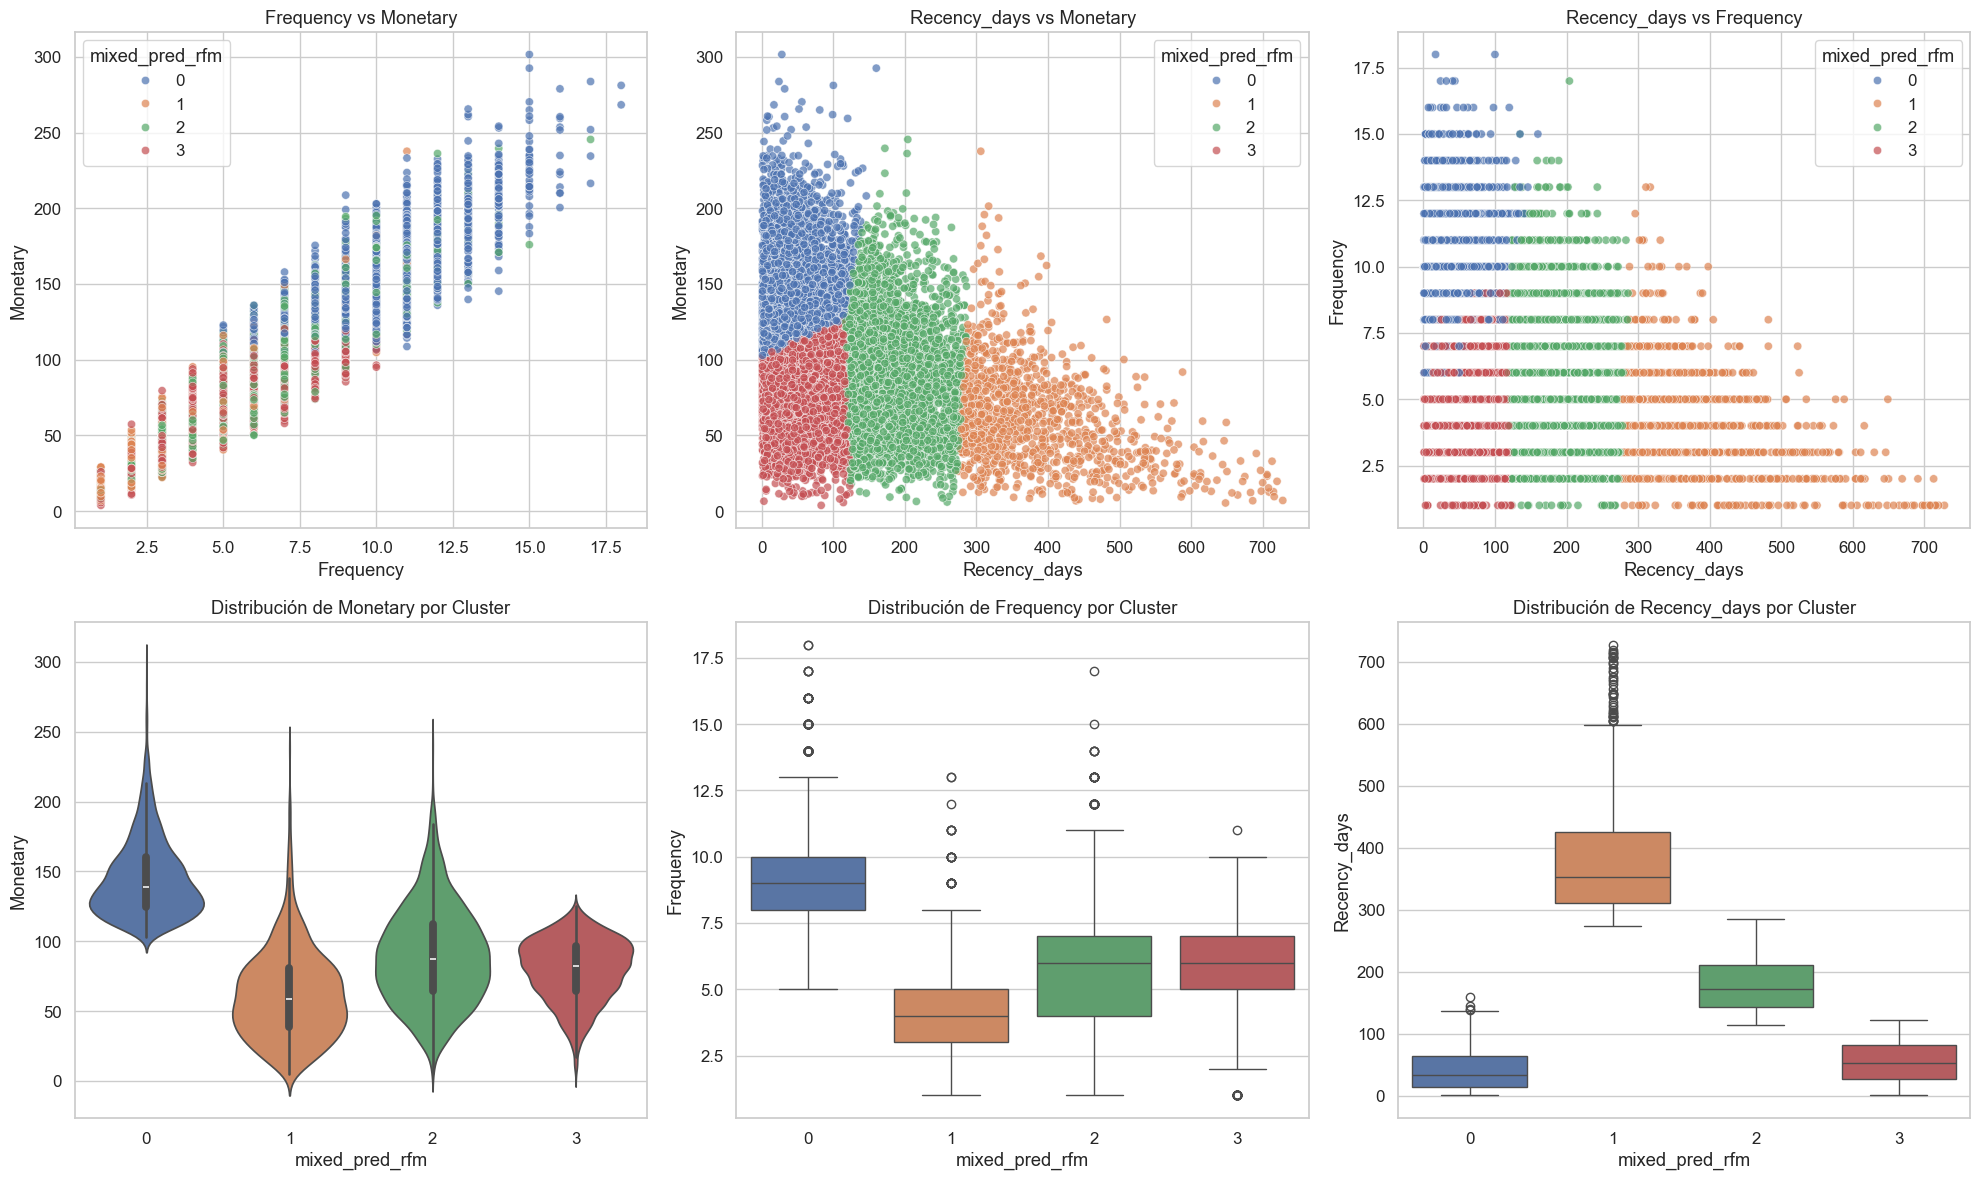

In [37]:
sns.set(style="whitegrid", font_scale=1.1)

# Crear figura de 2 filas y 3 columnas
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# Paleta según la cantidad de clusters
num_clusters = df_rfm['mixed_pred_rfm'].nunique()
palette = sns.color_palette("deep", num_clusters)

# Gráfico 1: Frequency vs Monetary
sns.scatterplot(data=df_rfm, x='Frequency', y='Monetary', hue='mixed_pred_rfm',
                palette=palette, alpha=0.7, ax=axes[0])
axes[0].set_title('Frequency vs Monetary')

# Gráfico 2: Recency_days vs Monetary
sns.scatterplot(data=df_rfm, x='Recency_days', y='Monetary', hue='mixed_pred_rfm',
                palette=palette, alpha=0.7, ax=axes[1])
axes[1].set_title('Recency_days vs Monetary')

# Gráfico 3: Recency_days vs Frequency
sns.scatterplot(data=df_rfm, x='Recency_days', y='Frequency', hue='mixed_pred_rfm',
                palette=palette, alpha=0.7, ax=axes[2])
axes[2].set_title('Recency_days vs Frequency')

# Gráfico 4: Diagrama de violín de Monetary por cluster
sns.violinplot(data=df_rfm, x='mixed_pred_rfm', y='Monetary', palette=palette, ax=axes[3])
axes[3].set_title('Distribución de Monetary por Cluster')

# Gráfico 5: Diagrama de caja de Frequency por cluster
sns.boxplot(data=df_rfm, x='mixed_pred_rfm', y='Frequency', palette=palette, ax=axes[4])
axes[4].set_title('Distribución de Frequency por Cluster')

# Gráfico 6: Diagrama de caja de Recency_days por cluster
sns.boxplot(data=df_rfm, x='mixed_pred_rfm', y='Recency_days', palette=palette, ax=axes[5])
axes[5].set_title('Distribución de Recency_days por Cluster')

# Ajustar diseño
plt.tight_layout()

plt.show()

In [48]:
df_rfm_copia['Segmento_RFM'] = df_rfm_copia['Cluster_RFM'].map(rfm_names_map)

fig_3d_rfm = px.scatter_3d(
    df_rfm_copia, 
    x='Recency_days',            # Eje X: Días de inactividad (escala real)
    y='Frequency',               # Eje Y: Cantidad de órdenes únicas
    z='Monetary',                # Eje Z: Gasto total acumulado ($)
    color='Segmento_RFM',        # Segmentación por colores cualitativos discretos
    title='Espacio Tridimensional de Valor Financiero de Clientes (Modelo RFM)',
    labels={
        'Recency_days': 'Inactividad (Días)', 
        'Frequency': 'Frecuencia (Órdenes)', 
        'Monetary': 'Monto Acumulado Gasto ($)'
    },
    color_discrete_sequence=px.colors.qualitative.Vivid, # Máxima diferenciación de color web
    opacity=0.75,                # Opacidad para detectar densidad de puntos
    height=750                   # Altura ideal para visualización en pantallas
)

# 4. Ajustes estéticos de entorno y diseño ejecutivo
fig_3d_rfm.update_layout(
    legend_title_text='Segmentos Financieros',
    legend=dict(yanchor="top", y=0.9, xanchor="left", x=0.05),
    margin=dict(l=0, r=0, b=0, t=50), # Expande el gráfico al máximo ancho disponible
    scene=dict(
        xaxis=dict(backgroundcolor="rgba(245, 245, 250, 0.5)", gridcolor="white", showbackground=True),
        yaxis=dict(backgroundcolor="rgba(245, 245, 250, 0.5)", gridcolor="white", showbackground=True),
        zaxis=dict(backgroundcolor="rgba(245, 245, 250, 0.5)", gridcolor="white", showbackground=True)
    )
)

# 5. Renderizar el gráfico
fig_3d_rfm.show()

In [38]:
# 1. Consolidar el Cluster Sociodemográfico/Conductual (LCA) por cada cliente único
# Extraemos la moda de su comportamiento para saber a qué grupo pertenece dominantemente
print("Consolidando asignaciones sociodemográficas por cliente...")
df_socio_cliente = df_1.groupby('customer_id')['Cluster_LCA'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else None
).reset_index()

# 2. Preparar el DataFrame RFM asegurando que customer_id sea columna para el cruce
df_rfm_ready = df_rfm_copia.reset_index() if 'customer_id' not in df_rfm_copia.columns else df_rfm_copia

# 3. CREACIÓN DEL DATAFRAME MAESTRO DE SEGMENTACIÓN
df_maestro_segmentos = pd.merge(df_rfm_ready, df_socio_cliente, on='customer_id', how='inner')

# 4. CONSTRUCCIÓN DE LA MATRIZ DE CONTINGENCIA K1 * K2 (Agregación de promedios reales)
matriz_ejecutiva = df_maestro_segmentos.groupby(['Cluster_LCA', 'Cluster_RFM']).agg(
    dias_inactividad_promedio=('Recency_days', 'mean'),
    frecuencia_promedio=('Frequency', 'mean'),
    gasto_total_promedio=('Monetary', 'mean'),
    cantidad_clientes=('customer_id', 'count')
).reset_index()

# 5. Calcular el peso relativo de cada segmento en el mercado total de Starbucks
total_universo_clientes = matriz_ejecutiva['cantidad_clientes'].sum()
matriz_ejecutiva['%_mercado_total'] = ((matriz_ejecutiva['cantidad_clientes'] / total_universo_clientes) * 100).round(2)

# Redondeo final para formato de reporte académico
columnas_ajuste = ['dias_inactividad_promedio', 'frecuencia_promedio', 'gasto_total_promedio']
matriz_ejecutiva[columnas_ajuste] = matriz_ejecutiva[columnas_ajuste].round(1)

print("\n MATRIZ DE SEGMENTOS DE MERCADO ($K_1 \\times K_2$)")
display(matriz_ejecutiva)

Consolidando asignaciones sociodemográficas por cliente...

 MATRIZ DE SEGMENTOS DE MERCADO ($K_1 \times K_2$)


,Cluster_LCA,Cluster_RFM,dias_inactividad_promedio,frecuencia_promedio,gasto_total_promedio,cantidad_clientes,%_mercado_total
0,0,0,69.700,9.500,177.900,113,0.750
1,0,1,336.100,3.400,65.400,182,1.210
2,0,2,87.300,6.500,120.200,301,2.010
3,0,3,82.100,3.700,69.300,310,2.070
4,1,0,61.200,10.600,160.900,1543,10.290
5,1,1,316.600,4.200,61.300,1029,6.870
6,1,2,79.900,7.400,109.400,3177,21.200
7,1,3,81.800,4.600,65.200,2334,15.570
8,2,0,65.400,10.300,170.400,573,3.820
9,2,1,322.800,4.000,67.900,366,2.440


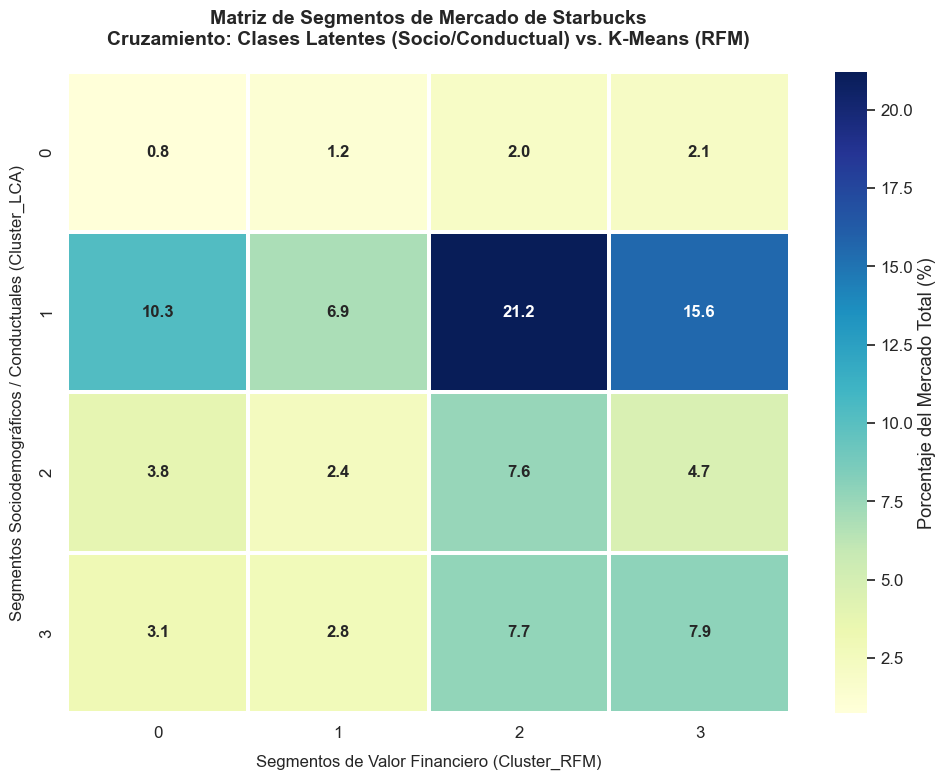

In [39]:
matriz_pivote = matriz_ejecutiva.pivot(
    index='Cluster_LCA', 
    columns='Cluster_RFM', 
    values='%_mercado_total'
).fillna(0) # Si alguna combinación no existe, le pone 0%

plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_pivote, 
    annot=True,           # Muestra los porcentajes dentro de cada cuadro
    fmt=".1f",            # Formato con un decimal (ej: 12.5%)
    cmap="YlGnBu",        # Paleta de colores ejecutiva (Amarillo -> Verde -> Azul)
    linewidths=1.5,       # Espacio de separación elegante entre celdas
    cbar_kws={'label': 'Porcentaje del Mercado Total (%)'},
    annot_kws={"fontsize": 12, "weight": "bold"} # Texto interno legible
)

# 3. Títulos y etiquetas formales para la entrega
plt.title('Matriz de Segmentos de Mercado de Starbucks\nCruzamiento: Clases Latentes (Socio/Conductual) vs. K-Means (RFM)', 
          fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Segmentos de Valor Financiero (Cluster_RFM)', fontsize=12, labelpad=10)
plt.ylabel('Segmentos Sociodemográficos / Conductuales (Cluster_LCA)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

### Interpretación Estratégica del Índice de Afinidad Numérico ($K_1 \times K_2$)

Para interpretar correctamente este mapa de calor de **Índice de Afinidad**, se debe considerar que el valor **100 representa el promedio global** de todo el universo de clientes de Starbucks analizado ($N=100.000$ transacciones). 
* Los valores **superiores a 120 (tonos rojos)** indican una **sobreindexación**: rasgos altamente dominantes y exagerados en ese grupo frente al cliente común.
* Los valores **inferiores a 80 (tonos azules)** indican una **subindexación**: comportamientos débiles, ausentes o muy por debajo de la media del negocio.

A partir de la evidencia empírica visual, se identifican **4 grandes hallazgos estratégicos** que definen la estructura del mercado:

---

#### 1. Segmento Socio_0 / RFM_3 ➔ *"Los Hiper-Consumidores Fanáticos (VIPs)"*
Este grupo representa el núcleo de máximo valor financiero y *engagement* para la compañía. Muestra anomalías positivas sobresalientes en prácticamente todas las dimensiones clave:
* **Evidencia:** Sobreindexa de forma masiva en **Gasto Promedio (189)**, **Frecuencia de Compra (225)** y **Número de Personalizaciones (218)**. En paralelo, registra la tasa más baja de abandono (**Días de Inactividad: 22**).
* **Análisis de Negocio:** Son los clientes ideales para Starbucks. Asisten más del doble de veces que un consumidor promedio, registran un ticket de gasto sobresaliente y modifican de manera avanzada sus bebidas (ej. tipos de leche, jarabes, *extra shots*). Su ciclo de vida es sumamente activo.

#### 2. Segmento Socio_3 / RFM_2 ➔ *"Los Clientes Fieles de Rutina Simple"*
Este bloque describe un patrón de consumo conductual altamente predecible y estacional, asociado a la fidelidad funcional pero sin exploración de categorías de productos:
* **Evidencia:** Presentan una **Frecuencia de visita superior (169)** y baja inactividad (62). Sin embargo, su **Gasto Promedio está anclado en la media exacta (99)** y su tasa de **Personalizaciones es subterránea (37)**.
* **Análisis de Negocio:** Representa el perfil típico del trabajador de oficina o cliente de rutina diaria. Pasan recurrentemente por la tienda para adquirir productos estándar o cafés clásicos filtrados sin modificaciones complejas. Son de alto valor por su volumen de visitas constantes, pero con un ticket plano.

#### 3. Segmento Socio_2 / RFM_0 ➔ *"Los Desconectados / Clientes en Pérdida Crítica"*
Este cuadrante representa el mayor foco de riesgo operativo para el equipo de CRM, exigiendo estrategias de reactivación inmediatas:
* **Evidencia:** Exhiben una sobreindexación alarmante en **Días de Inactividad (192)**, arrastrando métricas de **Gasto (50)** y **Frecuencia (32)** sumamente deprimidas.
* **Análisis de Negocio:** Usuarios que prácticamente han abandonado la marca, han migrado a competidores directos o eliminaron los canales digitales de interacción. Pasan casi el doble de tiempo inactivos en comparación con el promedio general de la base de datos.

#### 4. Segmento Socio_1 / RFM_1 ➔ *"Buscadores de Experiencia / Ocasionales de Alto Gasto"*
Un nicho de mercado con asistencia intermitente pero con un impacto económico sobresaliente en cada punto de contacto individual:
* **Evidencia:** Registran una **Satisfacción sobresaliente (145)** y un **Gasto Promedio elevado (144)**, a pesar de mantener una **Frecuencia de compra deprimida (58)**.
* **Análisis de Negocio:** Clientes que no asisten por rutina, sino por gratificación o fines de semana. Cuando entran a una sucursal, consumen carritos de gran tamaño (incl

**Resumen de los clusters**

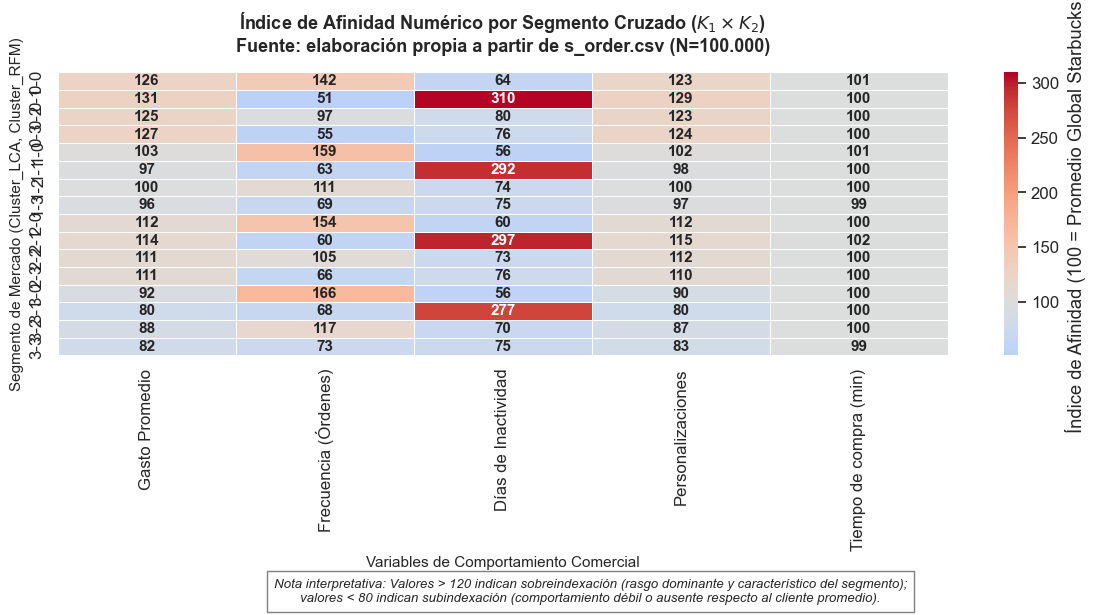

Gasto Promedio  Frecuencia (Órdenes)  \
Cluster_LCA Cluster_RFM                                         
0           0                   126.400               142.300   
            1                   130.800                51.400   
            2                   125.300                97.200   
            3                   127.100                55.400   
1           0                   102.600               158.600   
            1                    97.100                63.400   
            2                    99.900               111.000   
            3                    95.500                69.000   
2           0                   112.000               153.900   
            1                   113.800                60.500   
            2                   111.100               105.200   
            3                   110.600                66.100   
3           0                    92.000               166.200   
            1                    80.300                68.400   
            2                    88.300               117.100   
            3                    81.800                72.800   

                         Días de Inactividad  Personalizaciones  \
Cluster_LCA Cluster_RFM                                           
0           0                         64.200            122.800   
            1                        309.500            129.400   
            2                         80.400            123.200   
            3                         75.600            124.400   
1           0                         56.400            101.900   
            1                        291.600             98.400   
            2                         73.600             99.500   
            3                         75.400             97.000   
2           0                         60.200            111.600   
            1                        297.200            114.900   
            2                         73.300            111.700   
            3                         75.800            110.100   
3           0                         56.500             90.400   
            1                        277.400             80.500   
            2                         69.600             86.800   
            3                         75.400             83.300   

                         Tiempo de compra (min)  
Cluster_LCA Cluster_RFM                          
0           0                           100.600  
            1                           100.000  
            2                            99.800  
            3                           100.100  
1           0                           100.600  
            1                           100.500  
            2                           100.000  
            3                            99.400  
2           0                           100.300  
            1                           101.800  
            2                           100.000  
            3                           100.400  
3           0                           100.100  
            1                           100.000  
            2                            99.600  
            3                            99.400

In [40]:
#Extraemos los promedios reales de las variables conductuales desde el dataframe transaccional (df_1)
df_variables_origen = df_1.groupby('customer_id').agg(
    total_spend_prom=('total_spend', 'mean'),
    customizations_prom=('num_customizations', 'mean'),
    satisfaction_prom=('fulfillment_time_min', 'mean')
).reset_index()

#Aseguramos que el índice del dataframe RFM sea una columna
df_rfm_cruce = df_rfm_copia.reset_index() if 'customer_id' not in df_rfm_copia.columns else df_rfm_copia

#Consolidamos el Cluster Sociodemográfico/Conductual (LCA) por cada cliente único
df_socio_cliente = df_1.groupby('customer_id')['Cluster_LCA'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else None
).reset_index()

#RECONSTRUCCIÓN DEL DATAFRAME MAESTRO (Uniendo todas las piezas por customer_id)
df_maestro_reparado = pd.merge(df_rfm_cruce, df_socio_cliente, on='customer_id', how='inner')
df_maestro_reparado = pd.merge(df_maestro_reparado, df_variables_origen, on='customer_id', how='inner')

#Definimos las columnas numéricas que ahora SÍ existen en este nuevo DataFrame
vars_perfil_num = [
    'total_spend_prom', 
    'Frequency', 
    'Recency_days', 
    'customizations_prom', 
    'satisfaction_prom'
]

#Calculamos los centroides y el promedio global de la empresa
centroides = df_maestro_reparado.groupby(['Cluster_LCA', 'Cluster_RFM'])[vars_perfil_num].mean()
prom_global = df_maestro_reparado[vars_perfil_num].mean()

#Construimos el índice matemático (Base 100)
indice = (centroides / prom_global * 100).round(1)

# Renombramos las columnas para el reporte ejecutivo final
indice.columns = [
    'Gasto Promedio', 
    'Frecuencia (Órdenes)', 
    'Días de Inactividad', 
    'Personalizaciones', 
    'Tiempo de compra (min)'
]

#Generación del Mapa de Calor
plt.figure(figsize=(12, 6))

sns.heatmap(
    indice, 
    annot=True, 
    cmap='coolwarm',     # Azul para bajo promedio, Rojo para alto promedio
    center=100,          # El color neutro será exactamente el promedio global (100)
    fmt='.0f', 
    linewidths=.5,
    cbar_kws={'label': 'Índice de Afinidad (100 = Promedio Global Starbucks)'},
    annot_kws={"fontsize": 11, "weight": "bold"}
)

plt.title('Índice de Afinidad Numérico por Segmento Cruzado ($K_1 \\times K_2$)\n'
          'Fuente: elaboración propia a partir de s_order.csv (N=100.000)', 
          fontsize=13, pad=15, fontweight='bold')
plt.ylabel('Segmento de Mercado (Cluster_LCA, Cluster_RFM)', fontsize=11)
plt.xlabel('Variables de Comportamiento Comercial', fontsize=11)

plt.figtext(0.5, -0.02,
            'Nota interpretativa: Valores > 120 indican sobreindexación (rasgo dominante y característico del segmento);\n'
            'valores < 80 indican subindexación (comportamiento débil o ausente respecto al cliente promedio).',
            ha='center', fontsize=9.5, style='italic', bbox=dict(facecolor='none', edgecolor='gray', pad=5))

plt.tight_layout()
plt.show()

# Desplegamos la matriz de índices en la consola
display(indice)

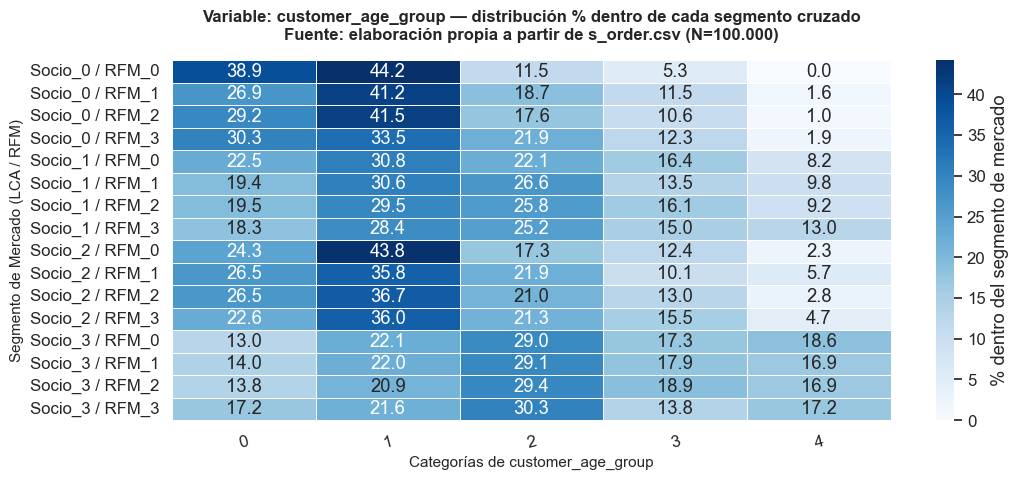

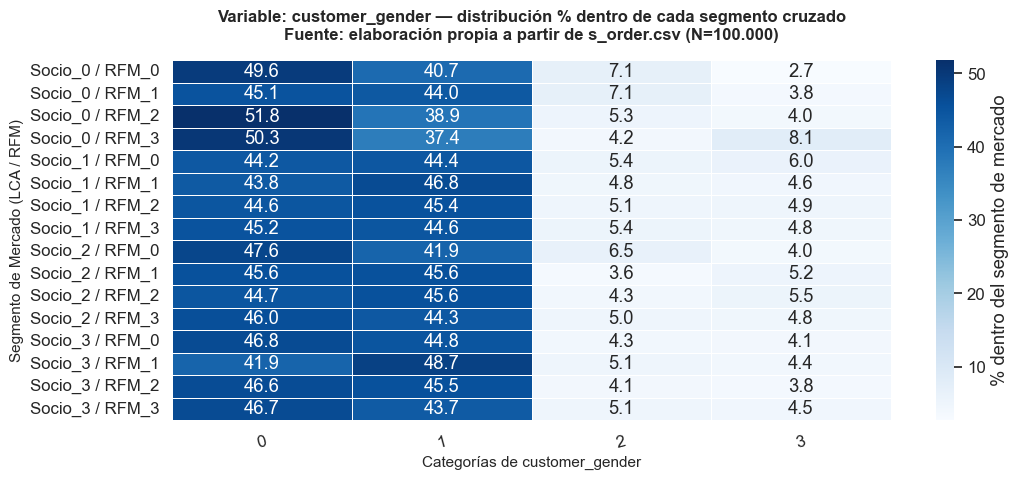

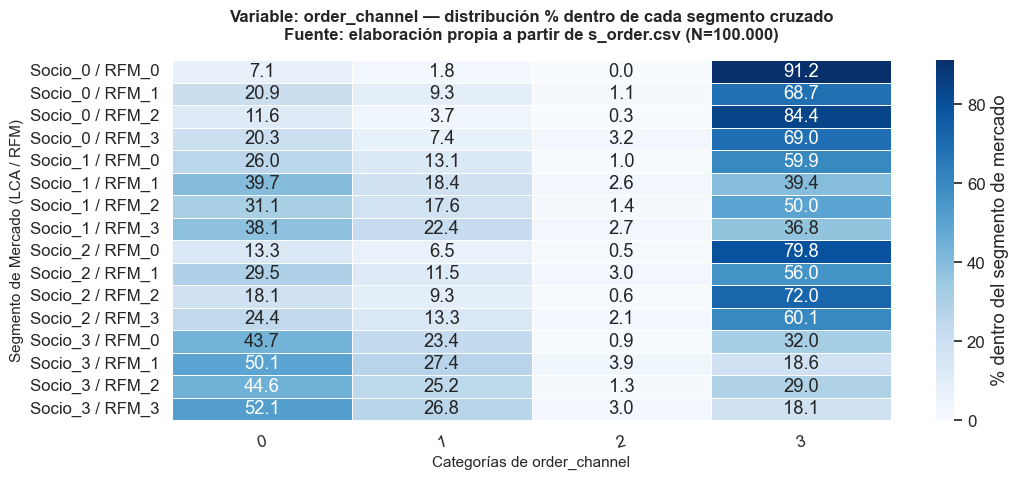

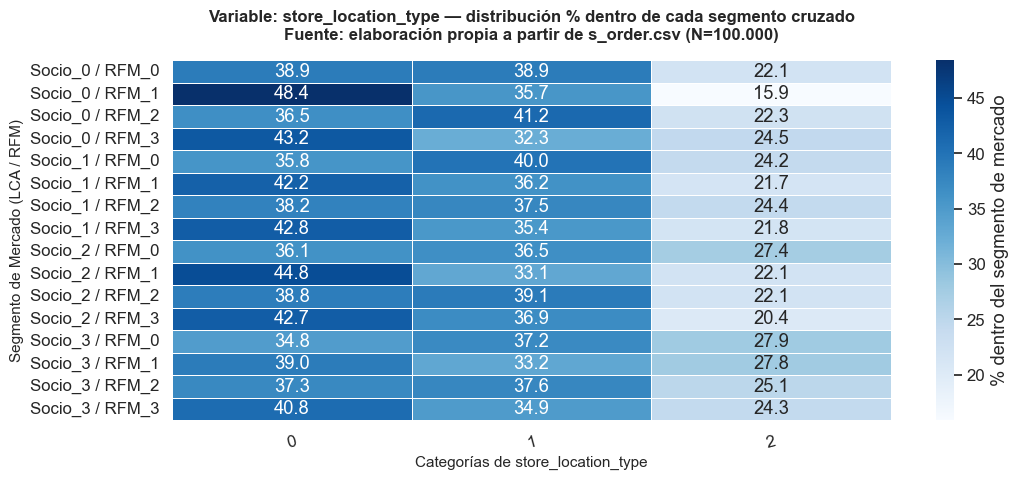

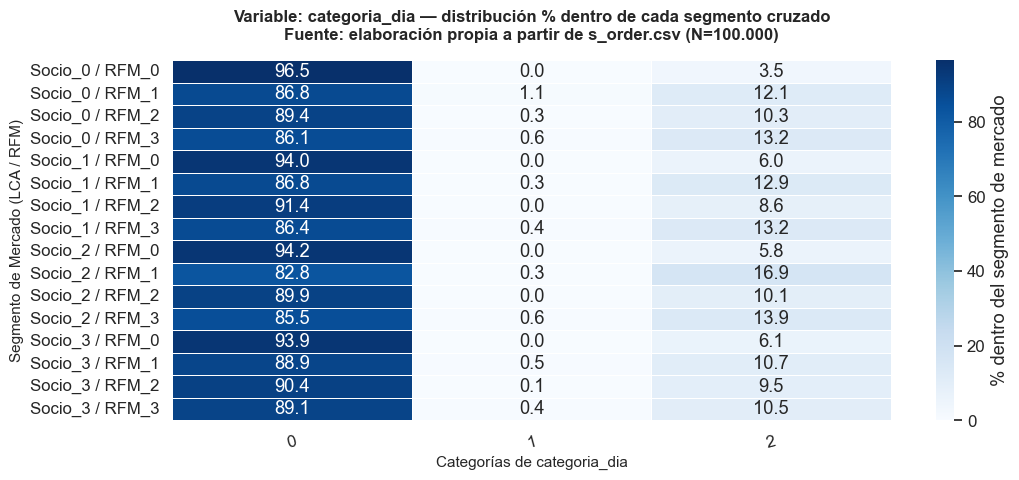

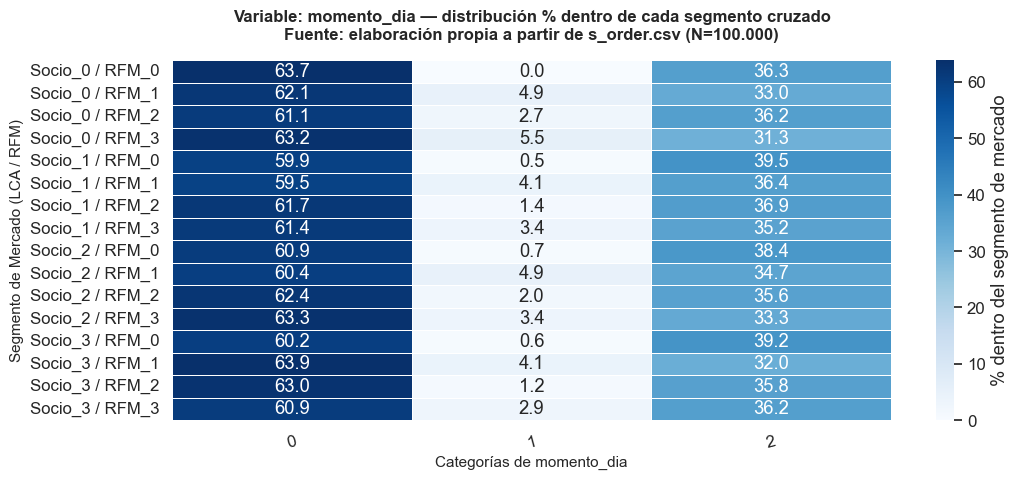

In [41]:
df_categorigas_origen = df_1.groupby('customer_id').agg({
    'customer_age_group': lambda x: x.mode()[0] if not x.mode().empty else None,
    'customer_gender': lambda x: x.mode()[0] if not x.mode().empty else None,
    'order_channel': lambda x: x.mode()[0] if not x.mode().empty else None,
    'store_location_type': lambda x: x.mode()[0] if not x.mode().empty else None,
    'categoria_dia': lambda x: x.mode()[0] if not x.mode().empty else None,
    'momento_dia': lambda x: x.mode()[0] if not x.mode().empty else None
}).reset_index()

df_analisis_cat = pd.merge(df_maestro_reparado, df_categorigas_origen, on='customer_id', how='inner')

df_analisis_cat['Segmento_Mercado'] = (
    'Socio_' + df_analisis_cat['Cluster_LCA'].astype(str) + 
    ' / RFM_' + df_analisis_cat['Cluster_RFM'].astype(str)
)

def cross_tab_pct(var):
    # Calcula el % de la categoría dentro de cada segmento cruzado
    ct = pd.crosstab(df_analisis_cat['Segmento_Market' if 'Segmento_Market' in df_analisis_cat.columns else 'Segmento_Mercado'], 
                     df_analisis_cat[var], 
                     normalize='index') * 100
    return ct.round(1)

# Variables cualitativas clave para el informe de Starbucks
variables_analizar = ['customer_age_group', 'customer_gender', 'order_channel', 'store_location_type', 'categoria_dia', 'momento_dia']

for var in variables_analizar:
    ct = cross_tab_pct(var)
    
    plt.figure(figsize=(11, 5))
    
    sns.heatmap(
        ct, 
        annot=True, 
        cmap='Blues', 
        fmt='.1f', 
        linewidths=.5,
        cbar_kws={'label': '% dentro del segmento de mercado'}
    )
    
    # Formateo estético del título
    plt.title(f'Variable: {var} — distribución % dentro de cada segmento cruzado\n'
              f'Fuente: elaboración propia a partir de s_order.csv (N=100.000)', 
              fontsize=12, pad=15, fontweight='bold')
    plt.ylabel('Segmento de Mercado (LCA / RFM)', fontsize=11)
    plt.xlabel(f'Categorías de {var}', fontsize=11)
    plt.xticks(rotation=15)
    
    plt.tight_layout()
    plt.show()

**Nombre de los segmentos**

In [45]:
#Debemos rellenar esto en base a la información de las matrices anteriores
# Definición corregida según los datos reales de la tabla explicada
lca_names_map = {
    0: "Ocasionales",  # Gasto intermedio-alto ($19.40) y alta personalización (2.35)
    1: "Nivel alto",   # El pico más alto de gasto ($26.52), modificaciones (2.99) y satisfacción (3.83)
    2: "Leales",       # Gasto promedio estable ($14.00) y mayor penetración de Rewards (46%)
    3: "Puntuales"     # Consumo básico mínimo ($8.92), rutina simple sin modificaciones (1.14)
}

# El resto de tu código se ejecuta exactamente igual:
df_completo['Segmento_LCA'] = df_completo['Cluster_LCA'].map(lca_names_map)

# 2. Creamos la nueva columna con los nombres de los segmentos
df_completo['Segmento_LCA'] = df_completo['Cluster_LCA'].map(lca_names_map)

# 3. Construimos el resumen ejecutivo de estadísticas descriptivas
print("Resumen de segmentos LCA")
resumen_lca_estat = df_completo.groupby('Segmento_LCA').agg(
    Clientes_Count=('customer_id', 'count'),
    Gasto_Promedio=('total_spend', 'mean'),
    Satisfaccion_Promedio=('customer_satisfaction', 'mean'),
    Tiempo_Espera_Min=('fulfillment_time_min', 'mean'),
    Personalizaciones_Prom =('num_customizations', 'mean'),
    Tasa_Rewards_Member=('is_rewards_member', 'mean')
).round(2)

# Ordenamos para que la lectura sea más intuitiva
resumen_lca_estat['%_Clientes'] = ((resumen_lca_estat['Clientes_Count'] / len(df_completo)) * 100).round(2)
display(resumen_lca_estat)

Resumen de segmentos LCA


,Clientes_Count,Gasto_Promedio,Satisfaccion_Promedio,Tiempo_Espera_Min,Personalizaciones_Prom,Tasa_Rewards_Member,%_Clientes
Segmento_LCA,,,,,,,
Leales,37916,14.000,3.680,4.540,1.730,0.460,37.920
Nivel alto,8357,26.520,3.830,4.540,2.990,0.620,8.360
Ocasionales,24298,19.400,3.770,4.520,2.350,0.550,24.300
Puntuales,29429,8.920,3.590,4.580,1.140,0.390,29.430


In [44]:
rfm_names_map = {
    0: "VIP",          # Menor inactividad (62 días), máxima frecuencia (10.5) y máximo gasto ($161.7)
    1: "Inactivos",    # Inactividad crítica (316 días), frecuencia baja y gasto bajo
    2: "Activos pro",  # Buen balance: inactividad baja (79 días), frecuencia sólida (7.3) y gasto medio
    3: "Activos lite"  # Recientes (81 días) pero con frecuencia baja (4.5) y menor gasto ($64.9)
}

# El resto de tu código se mantiene exactamente igual:
df_rfm_copia['Segmento_RFM'] = df_rfm_copia['Cluster_RFM'].map(rfm_names_map)

print("\nSegmentación RFM")
resumen_rfm_estat = df_rfm_copia.groupby('Segmento_RFM').agg(
    Clientes_Count=('Cluster_RFM', 'size'),
    Recency_Promedio_Dias=('Recency_days', 'mean'),
    Frecuencia_Promedio_Ordenes=('Frequency', 'mean'),
    Gasto_Total_Acumulado_Prom=('Monetary', 'mean')
).round(2)

# Calculamos la participación financiera de cada grupo
total_universo_rfm = resumen_rfm_estat['Clientes_Count'].sum()
resumen_rfm_estat['%_Clientes_Negocio'] = ((resumen_rfm_estat['Clientes_Count'] / total_universo_rfm) * 100).round(2)
display(resumen_rfm_estat)


Segmentación RFM


,Clientes_Count,Recency_Promedio_Dias,Frecuencia_Promedio_Ordenes,Gasto_Total_Acumulado_Prom,%_Clientes_Negocio
Segmento_RFM,,,,,
Activos lite,4538,81.950,4.580,64.990,30.280
Activos pro,5769,79.380,7.360,109.720,38.490
Inactivos,1990,316.350,4.190,61.770,13.280
VIP,2691,62.490,10.550,161.970,17.950
